# Projeto: Previsão de Churn (Abandono)

### Instalação

In [1]:
!pip install optuna

In [2]:
%pip install torch

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install pykan

Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install tabkanet

ERROR: Could not find a version that satisfies the requirement tabkanet (from versions: none)
ERROR: No matching distribution found for tabkanet
Note: you may need to restart the kernel to use updated packages.


In [5]:
%pip install einops

Note: you may need to restart the kernel to use updated packages.


In [6]:
import sys
sys.path.append("tabkanet")

### Importaçao de bibliotecas

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, mean_squared_error, confusion_matrix, roc_auc_score, roc_curve, precision_score, recall_score, f1_score, log_loss
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier
import optuna
import torch
from kan import KAN
from tabkanet.models import TabMLPNet
from tabkanet.tools import seed_everything, get_dataset, get_data_loader, train
from tabkanet.metrics import f1_score_macro

import numpy as np
import pandas as pd
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, mean_squared_error, roc_auc_score,
    precision_score, recall_score, f1_score, log_loss, confusion_matrix
)

/Users/laysearaujo/miniforge3/envs/test/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
import warnings
warnings.filterwarnings("ignore")

# Visualização e Separação de Dados

In [9]:
url = 'https://raw.githubusercontent.com/laysearaujo/churn-forecast/main/customer_churn_telecom_services.csv'
original_df = pd.read_csv(url)
original_df.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
6,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
7,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
8,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [10]:
original_df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Não há nenhuma chave única óbvia, como um **ID**, então não há necessidade de remover nenhuma coluna por identificação.

In [11]:
df = original_df.copy()  # Mantém uma cópia original para referência futura

In [12]:
df_yes = df[df['Churn'] == 'Yes']
df_no = df[df['Churn'] == 'No']

print(f"Tamanho da classe 'Yes': {len(df_yes)}")
print(f"Tamanho da classe 'No': {len(df_no)}")

Tamanho da classe 'Yes': 1869
Tamanho da classe 'No': 5174


In [13]:
# KFold para cada classe (k = 3)
k = 3
kf_yes = KFold(n_splits=k, shuffle=True, random_state=42)
kf_no = KFold(n_splits=k, shuffle=True, random_state=42)

folds_yes = []
folds_no = []

In [14]:
# Criando os 3 folds para a classe 'Yes'
for i, (train_idx, temp_idx) in enumerate(kf_yes.split(df_yes)):
    val_idx, test_idx = np.array_split(temp_idx, 2)  # Divide igualmente em validação e teste
    folds_yes.append((train_idx, val_idx, test_idx))

# Criando os 3 folds para a classe 'No'
for i, (train_idx, temp_idx) in enumerate(kf_no.split(df_no)):
    val_idx, test_idx = np.array_split(temp_idx, 2)
    folds_no.append((train_idx, val_idx, test_idx))

In [15]:
folds = []

for i in range(k):
    print(f"\n==== Fold {i+1} ====")

    # Combina os índices de treino, validação e teste das classes 'Yes' e 'No'
    train_idx = np.concatenate([folds_yes[i][0], folds_no[i][0]])
    val_idx = np.concatenate([folds_yes[i][1], folds_no[i][1]])
    test_idx = np.concatenate([folds_yes[i][2], folds_no[i][2]])

    # Obtém os dados correspondentes aos índices
    train_data = pd.concat([df_yes.iloc[folds_yes[i][0]], df_no.iloc[folds_no[i][0]]], ignore_index=True)
    val_data = pd.concat([df_yes.iloc[folds_yes[i][1]], df_no.iloc[folds_no[i][1]]], ignore_index=True)
    test_data = pd.concat([df_yes.iloc[folds_yes[i][2]], df_no.iloc[folds_no[i][2]]], ignore_index=True)

    print("\n(Antes do Oversampling no Treino)")
    print(f"  Treino - Yes: {sum(train_data['Churn'] == 'Yes')}, No: {sum(train_data['Churn'] == 'No')}")
    print(f"  Validação - Yes: {sum(val_data['Churn'] == 'Yes')}, No: {sum(val_data['Churn'] == 'No')}")
    print(f"  Teste - Yes: {sum(test_data['Churn'] == 'Yes')}, No: {sum(test_data['Churn'] == 'No')}")

    train_yes = train_data[train_data['Churn'] == 'Yes']
    train_no = train_data[train_data['Churn'] == 'No']

    size_yes = len(train_yes)
    size_no = len(train_no)

    if size_yes < size_no:
        num_repeats = size_no // size_yes
        remainder = size_no % size_yes

        # Duplica completamente a classe menor
        train_yes_oversampled = pd.concat([train_yes] * num_repeats, ignore_index=True)
        train_yes_oversampled = pd.concat([train_yes_oversampled, train_yes.iloc[:remainder]], ignore_index=True)
    else:
        train_yes_oversampled = train_yes  # Se já estiver balanceado, mantém igual

    # Junta os dados balanceados
    train_data = pd.concat([train_yes_oversampled, train_no], ignore_index=True)

    # Embaralha os dados para evitar padrões artificiais
    train_data = train_data.sample(frac=1, random_state=42).reset_index(drop=True)

    folds.append((train_data, val_data, test_data))

    print("\n(Depois do Oversampling no Treino)")
    print(f"  Treino - Yes: {sum(train_data['Churn'] == 'Yes')}, No: {sum(train_data['Churn'] == 'No')}")
    print(f"  Validação - Yes: {sum(val_data['Churn'] == 'Yes')}, No: {sum(val_data['Churn'] == 'No')}")
    print(f"  Teste - Yes: {sum(test_data['Churn'] == 'Yes')}, No: {sum(test_data['Churn'] == 'No')}")
    print('\n')


==== Fold 1 ====

(Antes do Oversampling no Treino)
  Treino - Yes: 1246, No: 3449
  Validação - Yes: 312, No: 863
  Teste - Yes: 311, No: 862

(Depois do Oversampling no Treino)
  Treino - Yes: 3449, No: 3449
  Validação - Yes: 312, No: 863
  Teste - Yes: 311, No: 862



==== Fold 2 ====

(Antes do Oversampling no Treino)
  Treino - Yes: 1246, No: 3449
  Validação - Yes: 312, No: 863
  Teste - Yes: 311, No: 862

(Depois do Oversampling no Treino)
  Treino - Yes: 3449, No: 3449
  Validação - Yes: 312, No: 863
  Teste - Yes: 311, No: 862



==== Fold 3 ====

(Antes do Oversampling no Treino)
  Treino - Yes: 1246, No: 3450
  Validação - Yes: 312, No: 862
  Teste - Yes: 311, No: 862

(Depois do Oversampling no Treino)
  Treino - Yes: 3450, No: 3450
  Validação - Yes: 312, No: 862
  Teste - Yes: 311, No: 862




# Pré-processamento mínimo

Fazemos a análise exploratória apenas no conjunto de treino do primeiro fold para definir transformações de maneira imparcial e sem vazamento de dados. Depois que decidirmos quais transformações aplicar, aplicamos as mesmas regras em todos os outros folds (por exemplo, padronização de escalas, criação de categorias, etc.).

In [16]:
# Pegando apenas o conjunto de treino do primeiro fold
train_data = folds[0][0]
train_data.shape

(6898, 20)

## Distribuição da variável alvo (Churn)

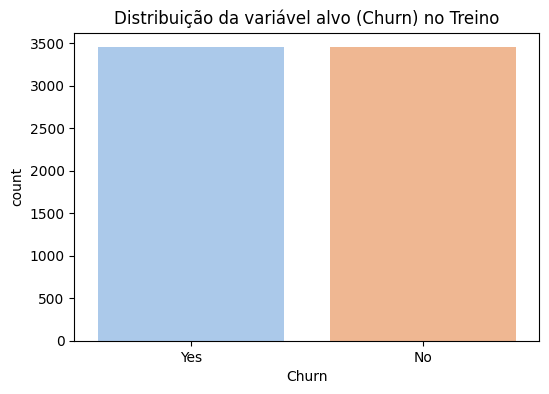

In [17]:
plt.figure(figsize=(6, 4))
sns.countplot(x=train_data["Churn"], palette="pastel")
plt.title("Distribuição da variável alvo (Churn) no Treino")
plt.show()

Como já haviamos feito o oversampling na base de treinamento não vamos precisar nos preocupar com desbalanceamento

## Verificar dados ausentes

In [18]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6898 entries, 0 to 6897
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            6898 non-null   object 
 1   SeniorCitizen     6898 non-null   int64  
 2   Partner           6898 non-null   object 
 3   Dependents        6898 non-null   object 
 4   tenure            6898 non-null   int64  
 5   PhoneService      6898 non-null   object 
 6   MultipleLines     6898 non-null   object 
 7   InternetService   6898 non-null   object 
 8   OnlineSecurity    6898 non-null   object 
 9   OnlineBackup      6898 non-null   object 
 10  DeviceProtection  6898 non-null   object 
 11  TechSupport       6898 non-null   object 
 12  StreamingTV       6898 non-null   object 
 13  StreamingMovies   6898 non-null   object 
 14  Contract          6898 non-null   object 
 15  PaperlessBilling  6898 non-null   object 
 16  PaymentMethod     6898 non-null   object 


In [19]:
train_data.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        6
Churn               0
dtype: int64

Valores ausentes:

* A coluna TotalCharges tem 6 valores ausentes (6892 em 6898 não nulos).

Tipos de dados:

* Variáveis categóricas (object): gender, Partner, Dependents, etc.
* Variáveis numéricas (int64, float64): tenure, MonthlyCharges, TotalCharges e SeniorCitizen.


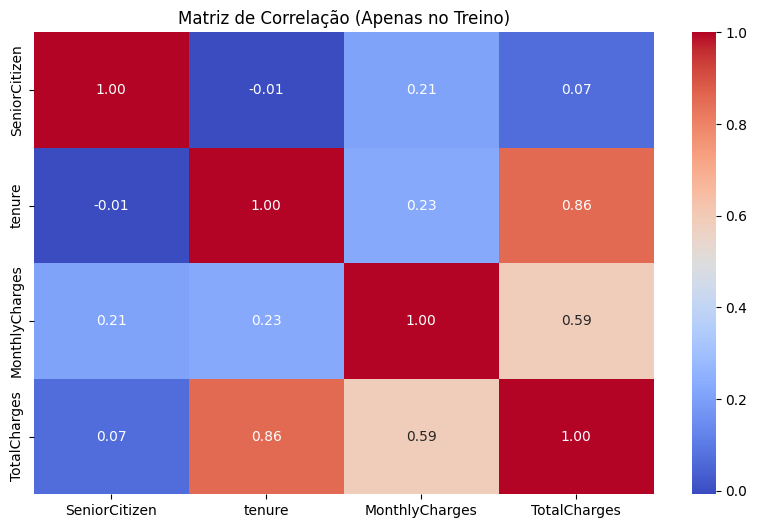

In [20]:
# Correlação entre variáveis numéricas
numeric_cols = train_data.select_dtypes(include=['number']).columns
plt.figure(figsize=(10, 6))
sns.heatmap(train_data[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação (Apenas no Treino)")
plt.show()

A correlação entre TotalCharges e tenure (0.86) e entre TotalCharges e MonthlyCharges (0.59) indica que essa variável tem uma relação forte com outras. Isso sugere que simplesmente removê-la pode levar à perda de uma informação importante.

Vamos analisar as linhas pra entender o que pode tá acontencendo.

In [21]:
train_data[train_data.isnull().any(axis=1)]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
345,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
409,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
3865,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
4344,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
4635,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6373,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No


Todas as linhas que contém NaN é apenas na coluna de TotalCharges e todas essas linhas tem em comum que o Tenure é 0, ou seja, o número de meses que o cliente permaneceu na empresa, como essa váriavel é zero, faz mais sentido deixar as linhas NaN na coluna TotalCharges como 0 também.

In [22]:
train_data['TotalCharges'] = train_data['TotalCharges'].fillna(0)

In [23]:
train_data.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Agora não temos mais dados faltantes

## One-Hot Encoding para variáveis categóricas com múltiplas categorias

In [24]:
def preprocess_one_hot(data):
    """Aplica One-Hot Encoding nas colunas categóricas pré-definidas."""
    categorical_cols = ['InternetService', 'Contract', 'PaymentMethod', 'MultipleLines',
                        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
                        'StreamingTV', 'StreamingMovies']
    return pd.get_dummies(data, columns=categorical_cols, drop_first=True)


In [25]:
train_data = preprocess_one_hot(train_data)

## Label Encoding para variáveis binárias

In [26]:
def preprocess_label_encoding(data):
    """Aplica Label Encoding nas colunas binárias pré-definidas."""
    binary_cols = ["gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"]

    # Mapeamento atualizado para evitar NaN
    mapping = {
        "Yes": 1, "No": 0,
        "Male": 1, "Female": 0  # Adicionado para tratar a coluna "gender"
    }

    for col in binary_cols:
        if col in data.columns:  # Verifica se a coluna existe antes de mapear
            data[col] = data[col].map(mapping)

    return data

In [27]:
train_data = preprocess_label_encoding(train_data)

## Verifique se o dataset está pronto (com o mínimo de alteracões possível nesse primeiro caso)

In [28]:
train_data.dtypes

gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
InternetService_Fiber optic                 bool
InternetService_No                          bool
Contract_One year                           bool
Contract_Two year                           bool
PaymentMethod_Credit card (automatic)       bool
PaymentMethod_Electronic check              bool
PaymentMethod_Mailed check                  bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes  

Como não há colunas do tipo object podemos fazer o treinamento

In [29]:
train_data.isnull().sum()

gender                                   0
SeniorCitizen                            0
Partner                                  0
Dependents                               0
tenure                                   0
PhoneService                             0
PaperlessBilling                         0
MonthlyCharges                           0
TotalCharges                             0
Churn                                    0
InternetService_Fiber optic              0
InternetService_No                       0
Contract_One year                        0
Contract_Two year                        0
PaymentMethod_Credit card (automatic)    0
PaymentMethod_Electronic check           0
PaymentMethod_Mailed check               0
MultipleLines_No phone service           0
MultipleLines_Yes                        0
OnlineSecurity_No internet service       0
OnlineSecurity_Yes                       0
OnlineBackup_No internet service         0
OnlineBackup_Yes                         0
DeviceProte

# Treinamento Inicial

Fazer as mesmas transformações no fold de teste também

In [30]:
val_data = folds[0][1]
test_data = folds[0][2]

In [31]:
val_data['TotalCharges'] = val_data['TotalCharges'].fillna(0)
test_data['TotalCharges'] = test_data['TotalCharges'].fillna(0)

In [32]:
val_data = preprocess_one_hot(val_data)
test_data = preprocess_one_hot(test_data)

In [33]:
val_data = preprocess_label_encoding(val_data)
test_data = preprocess_label_encoding(test_data)

In [34]:
# Separando as features (X) e os rótulos (y) para o treino
X_train = train_data.drop(columns=['Churn'])  # Features (dados de entrada) para treino
y_train = train_data['Churn']  # Rótulos (target) para treino

In [35]:
# Separando as features (X) e os rótulos (y) para a validação
X_val = val_data.drop(columns=['Churn'])  # Features (dados de entrada) para validação
y_val = val_data['Churn']  # Rótulos (target) para validação

In [36]:
# Separando as features (X) e os rótulos (y) para o teste
X_test = test_data.drop(columns=['Churn'])  # Features (dados de entrada) para teste
y_test = test_data['Churn']  # Rótulos (target) para teste

## MLP

Com ReLU, Adam, taxa de aprendizado 0.001.

In [37]:
# Treinando MLP básico
mlp = MLPClassifier(hidden_layer_sizes=(100,),  # Número de neurônios nas camadas ocultas
                    activation='relu',          # Função de ativação ReLU
                    solver='adam',              # Otimizador Adam
                    learning_rate_init=0.001,   # Taxa de aprendizado de 0.001
                    max_iter=500,               # Número máximo de iterações
                    random_state=42)            # Fixando a semente para reprodutibilidade

In [38]:
# Treinando o modelo
mlp.fit(X_train, y_train)

MLPClassifier(max_iter=500, random_state=42)

In [39]:
# Validando o modelo com o conjunto de validação
val_predictions = mlp.predict(X_val)

In [40]:
val_accuracy = accuracy_score(y_val, val_predictions)
print(f'Validation Accuracy: {val_accuracy}')

Validation Accuracy: 0.7787234042553192


In [41]:
# Realizando previsões com os dados de teste
y_pred = mlp.predict(X_test)

In [42]:
# Avaliando o modelo nos dados de teste
test_accuracy = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {test_accuracy}')

Test Accuracy: 0.7774936061381074


In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Fazendo previsões no conjunto de teste
y_test_pred = mlp.predict(X_test)

# Calculando métricas
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
conf_matrix = confusion_matrix(y_test, y_test_pred)

# Exibindo os resultados
print(f"Acurácia: {accuracy:.4f}")
print(f"Precisão: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print("\nMatriz de Confusão:")
print(conf_matrix)

# Relatório detalhado
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_test_pred))


Acurácia: 0.7775
Precisão: 0.5635
Recall: 0.7138
F1-score: 0.6298

Matriz de Confusão:
[[690 172]
 [ 89 222]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.89      0.80      0.84       862
           1       0.56      0.71      0.63       311

    accuracy                           0.78      1173
   macro avg       0.72      0.76      0.74      1173
weighted avg       0.80      0.78      0.78      1173



## Random Forest

Com hiperparâmetros padrão.

In [44]:
# Treinando Random Forest básico
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [45]:
# Fazendo previsões
y_val_pred = rf.predict(X_val)
y_test_pred = rf.predict(X_test)

In [46]:
# Calculando a acurácia
val_acc = accuracy_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)

In [47]:
print(f"Acurácia na validação: {val_acc:.4f}")
print(f"Acurácia no teste: {test_acc:.4f}")

Acurácia na validação: 0.7906
Acurácia no teste: 0.7724


In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Fazendo previsões no conjunto de teste
y_test_pred = rf.predict(X_test)

# Calculando métricas
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
conf_matrix = confusion_matrix(y_test, y_test_pred)

# Exibindo os resultados
print(f"Acurácia: {accuracy:.4f}")
print(f"Precisão: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print("\nMatriz de Confusão:")
print(conf_matrix)

# Relatório detalhado
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_test_pred))


Acurácia: 0.7724
Precisão: 0.5753
Recall: 0.5402
F1-score: 0.5572

Matriz de Confusão:
[[738 124]
 [143 168]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       862
           1       0.58      0.54      0.56       311

    accuracy                           0.77      1173
   macro avg       0.71      0.70      0.70      1173
weighted avg       0.77      0.77      0.77      1173



# Ajuste iterativo dos dados

## Identificar outliers

<Figure size 1200x600 with 0 Axes>

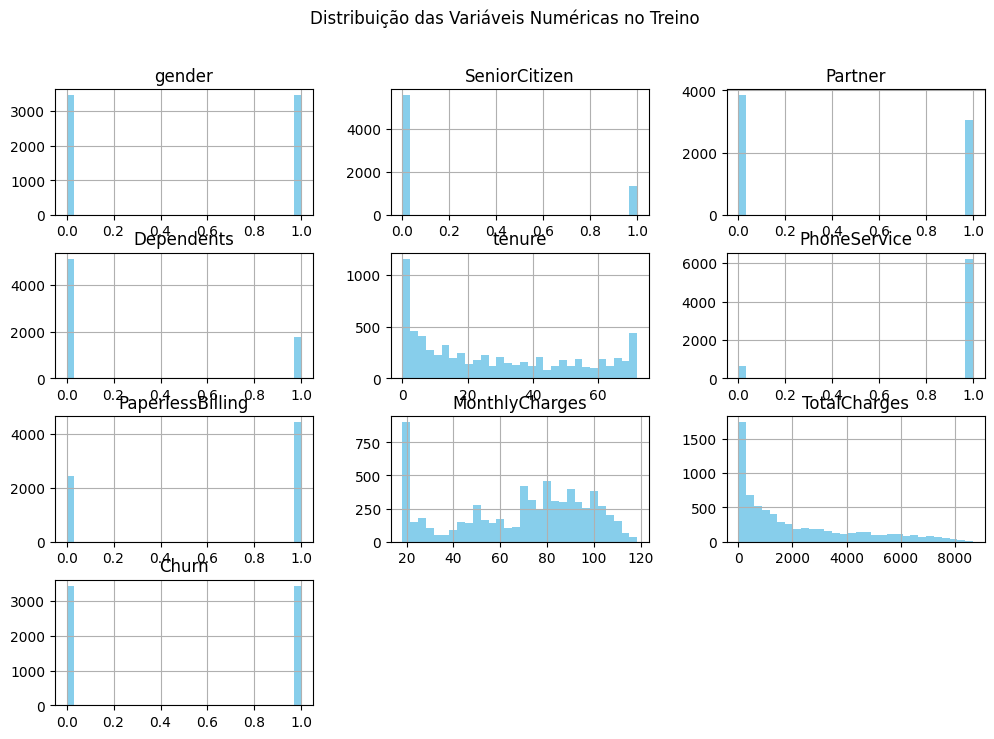

In [49]:
# Distribuição de variáveis numéricas
numeric_cols = train_data.select_dtypes(include=['number']).columns

plt.figure(figsize=(12, 6))
train_data[numeric_cols].hist(bins=30, figsize=(12, 8), color="skyblue")
plt.suptitle("Distribuição das Variáveis Numéricas no Treino")
plt.show()

* SeniorCitizen (Binária)
  
  Só assume os valores 0 e 1, então já está no formato adequado.

* tenure (Tempo de contrato)
  
  Distribuição enviesada à esquerda (muitos valores pequenos).

  Pode ser normalizado (MinMaxScaler).

* MonthlyCharges (Cobrança mensal)
  
  Distribuição aproximadamente normal, mas com um pico inicial.
  
  Pode ser normalizado, dependendo do modelo escolhido.

* TotalCharges

  Tem valores ausentes e está altamente correlacionado com tenure.
  
  Parece seguir um padrão semelhante ao tenure, o que faz sentido (clientes com mais tempo acumulam mais cobranças).

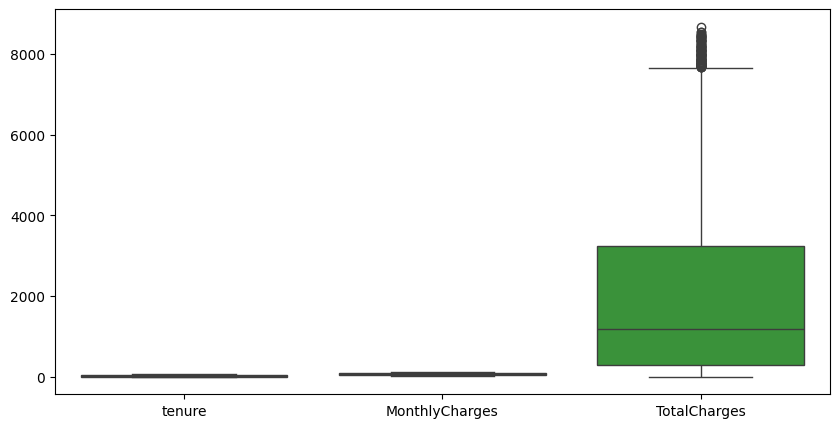

In [50]:
# Identificar outliers
plt.figure(figsize=(10,5))
sns.boxplot(data=train_data[["tenure", "MonthlyCharges", "TotalCharges"]])
plt.show()

Como o objetivo é prever o Churn, os valores muito altos de TotalCharges não necessariamente são "ruídos" nos dados. Na verdade, eles podem conter informações valiosas, já que:

1. Clientes com TotalCharges alto podem ser antigos e, geralmente, têm menos chance de churn (se mantiveram na empresa por muito tempo).
2. Clientes com TotalCharges baixo podem ser novos clientes, que podem estar mais propensos a cancelar (Churn).

**Decisão:**

Em vez de remover os outliers, faz sentido normalizar os valores para que TotalCharges não tenha um impacto desproporcional no modelo.

Além disso, podemos criar bins (faixas) para TotalCharges e ver se existe um padrão entre os grupos e a taxa de churn.

## Transformações de Variáveis

### Tenure

A variável tenure representa o tempo de permanência do cliente.
Os intervalos podem ser definidos com base na distribuição dos dados. Para isso, podemos:

In [51]:
train_data["tenure"].describe()

count    6898.000000
mean       27.897941
std        23.894147
min         0.000000
25%         5.000000
50%        22.000000
75%        49.000000
max        72.000000
Name: tenure, dtype: float64

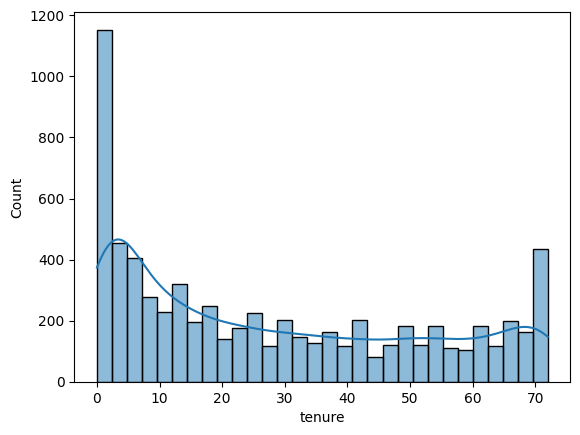

In [52]:
sns.histplot(train_data["tenure"], bins=30, kde=True)
plt.show()

A distribuição de tenure (tempo de permanência do cliente) na imagem mostra que:

1. Há um grande número de clientes com tenure baixo (próximo de 0), o que indica um alto volume de clientes recentes.

2. A distribuição parece bastante dispersa, com valores variando de 0 a 70 meses.

\\
**Ajustando os bins de tenure**


Os bins ([0, 6, 12, 24, 48, 72]) fazem sentido, podemos refiná-los com base na distribuição:

* Clientes Novos (0-6 meses)

* Clientes Iniciais (6-12 meses)

* Clientes Estáveis (1-2 anos)

* Clientes Fiéis (2-4 anos)

* Clientes de Longo Prazo (4-6 anos)

In [53]:
def categorize_tenure(df):
    df["tenure_group"] = pd.cut(df["tenure"],
                                bins=[-1, 6, 12, 24, 48, 72],
                                labels=["0-6m", "6-12m", "1-2y", "2-4y", "4-6y"],
                                right=True)
    return df

In [54]:
train_data = categorize_tenure(train_data)

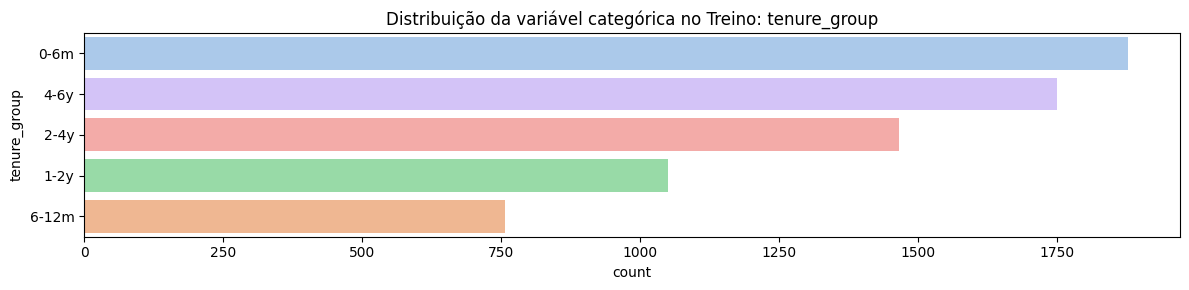

In [55]:
categorical_cols = ['tenure_group']

plt.figure(figsize=(12, len(categorical_cols) * 3))
for i, col in enumerate(categorical_cols):
    plt.subplot(len(categorical_cols), 1, i + 1)
    sns.countplot(y=train_data[col], hue=train_data[col], palette="pastel", order=train_data[col].value_counts().index, legend=False)
    plt.title(f"Distribuição da variável categórica no Treino: {col}")

plt.tight_layout()
plt.show()

### MonthlyCharges

In [56]:
train_data["MonthlyCharges"].describe()

count    6898.000000
mean       68.058169
std        28.916253
min        18.250000
25%        45.300000
50%        74.750000
75%        91.050000
max       118.600000
Name: MonthlyCharges, dtype: float64

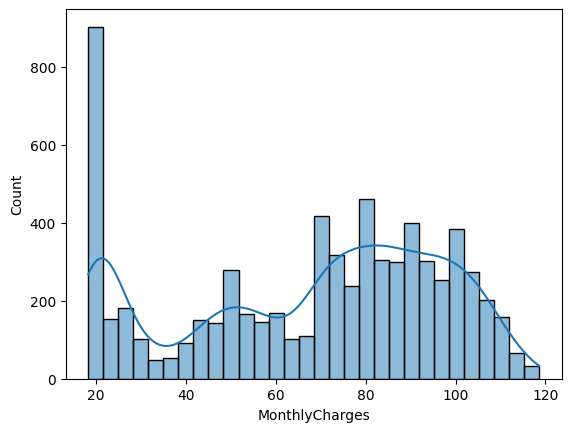

In [57]:
sns.histplot(train_data["MonthlyCharges"], bins=30, kde=True)
plt.show()

**Distribuição Assimétrica:** A maioria dos valores está concentrada na faixa mais baixa (próximo de 20–40), e há uma cauda longa à direita. Isso indica que a maior parte dos clientes paga valores mais baixos, mas há alguns com cobranças bem mais altas.

**Picos e Agrupamentos:** Existem vários picos ao longo do gráfico, sugerindo que certas faixas de preço são mais comuns. Pode ser um reflexo de diferentes planos ou pacotes oferecidos pela empresa.

**Valores Mínimo e Máximo:**

Mínimo: 18,25

Máximo: 118,60

Média: 68,05

* Mediana: 74,75 (isso mostra que a distribuição tem uma leve inclinação para valores menores)

\\
Podemos dividir pelos quartis (25%, 50%, 75%)

In [58]:
def categorize_monthly_charges(df):
    df["monthly_charges_group"] = pd.cut(df["MonthlyCharges"],
                                bins=[-1, 45.30, 74.75, 91.05, 120],
                                labels=["Low", "Medium", "High", "Very High"],
                                right=True)
    return df

In [59]:
train_data = categorize_monthly_charges(train_data)

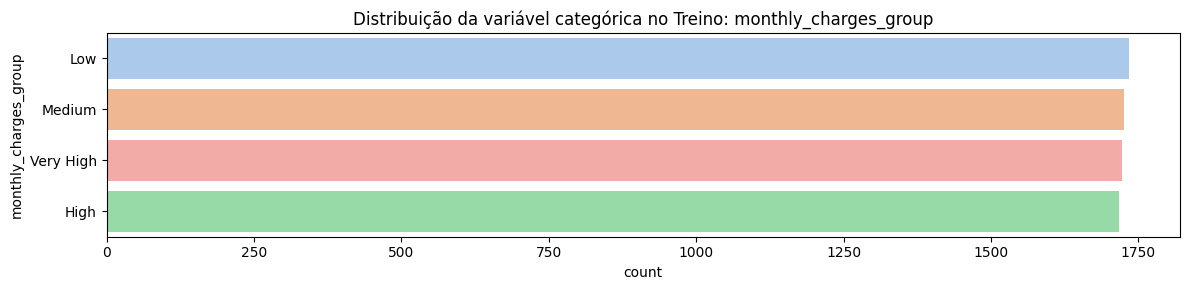

In [60]:
categorical_cols = ['monthly_charges_group']

plt.figure(figsize=(12, len(categorical_cols) * 3))
for i, col in enumerate(categorical_cols):
    plt.subplot(len(categorical_cols), 1, i + 1)
    sns.countplot(y=train_data[col], hue=train_data[col], palette="pastel", order=train_data[col].value_counts().index, legend=False)
    plt.title(f"Distribuição da variável categórica no Treino: {col}")

plt.tight_layout()
plt.show()

### TotalCharges

In [61]:
train_data["TotalCharges"].describe()

count    6898.000000
mean     2053.810322
std      2172.832531
min         0.000000
25%       281.000000
50%      1178.575000
75%      3232.612500
max      8670.100000
Name: TotalCharges, dtype: float64

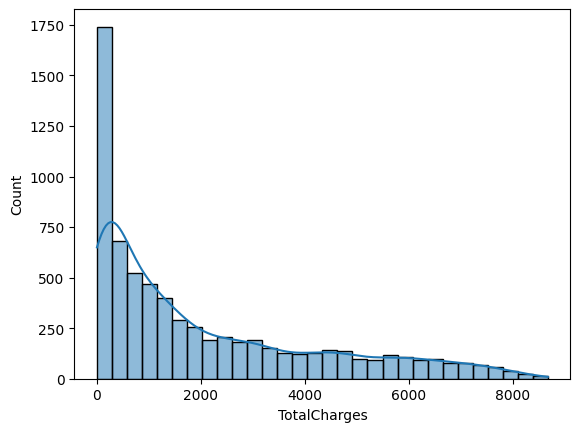

In [62]:
sns.histplot(train_data["TotalCharges"], bins=30, kde=True)
plt.show()

In [63]:
def categorize_total_changes(df):
    df["total_charges_group"] = pd.cut(df["TotalCharges"],
                                bins=[-1, 281, 1178.58, 3232.61, 9980],
                                labels=["Low", "Medium", "High", "Very High"],
                                right=True)
    return df

In [64]:
train_data = categorize_total_changes(train_data)

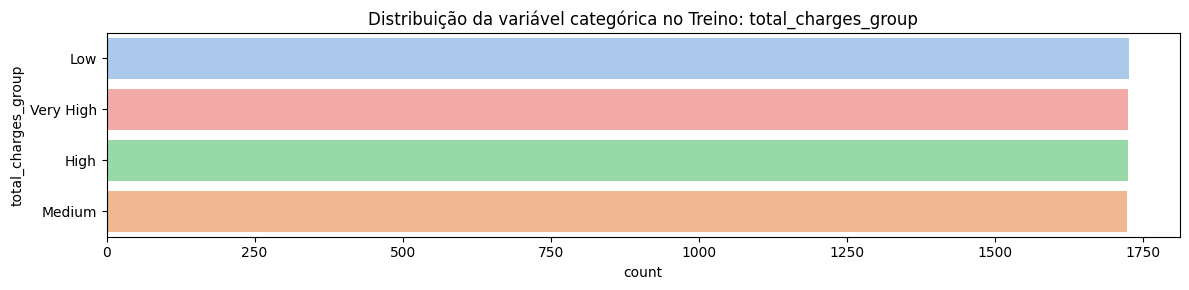

In [65]:
categorical_cols = ['total_charges_group']

plt.figure(figsize=(12, len(categorical_cols) * 3))
for i, col in enumerate(categorical_cols):
    plt.subplot(len(categorical_cols), 1, i + 1)
    sns.countplot(y=train_data[col], hue=train_data[col], palette="pastel", order=train_data[col].value_counts().index, legend=False)
    plt.title(f"Distribuição da variável categórica no Treino: {col}")

plt.tight_layout()
plt.show()

### Normalização


As colunas numéricas que devem ser normalizadas são: "tenure", "MonthlyCharges", "TotalCharges". Usamos a normalização para que os valores fiquem em um intervalo [0, 1].

In [66]:
def normalize(df):
  numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
  scaler = MinMaxScaler()
  df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
  return df

In [67]:
train_data = normalize(train_data)

In [68]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6898 entries, 0 to 6897
Data columns (total 34 columns):
 #   Column                                 Non-Null Count  Dtype   
---  ------                                 --------------  -----   
 0   gender                                 6898 non-null   int64   
 1   SeniorCitizen                          6898 non-null   int64   
 2   Partner                                6898 non-null   int64   
 3   Dependents                             6898 non-null   int64   
 4   tenure                                 6898 non-null   float64 
 5   PhoneService                           6898 non-null   int64   
 6   PaperlessBilling                       6898 non-null   int64   
 7   MonthlyCharges                         6898 non-null   float64 
 8   TotalCharges                           6898 non-null   float64 
 9   Churn                                  6898 non-null   int64   
 10  InternetService_Fiber optic            6898 non-null   bool 

### Explicação

<Figure size 1200x600 with 0 Axes>

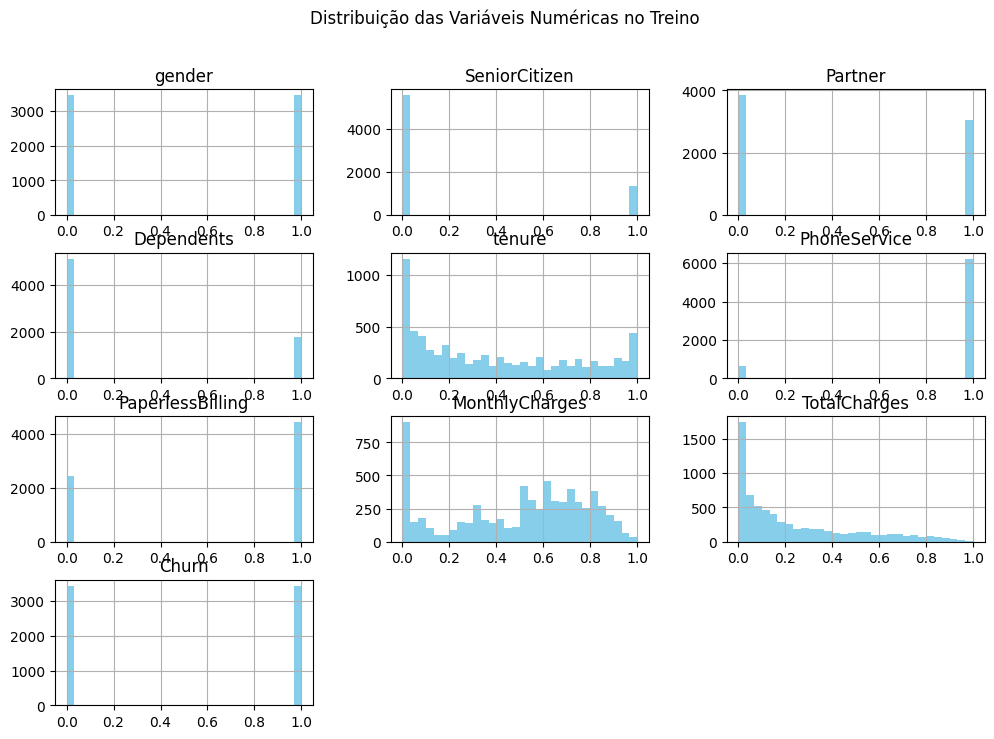

In [69]:
# Distribuição de variáveis numéricas
numeric_cols = train_data.select_dtypes(include=['number']).columns

plt.figure(figsize=(12, 6))
train_data[numeric_cols].hist(bins=30, figsize=(12, 8), color="skyblue")
plt.suptitle("Distribuição das Variáveis Numéricas no Treino")
plt.show()

Percebemos que o tenure, MontlyCharges e TotalCharges estão normaliados, ou seja, seus valores estão entre 0 e 1

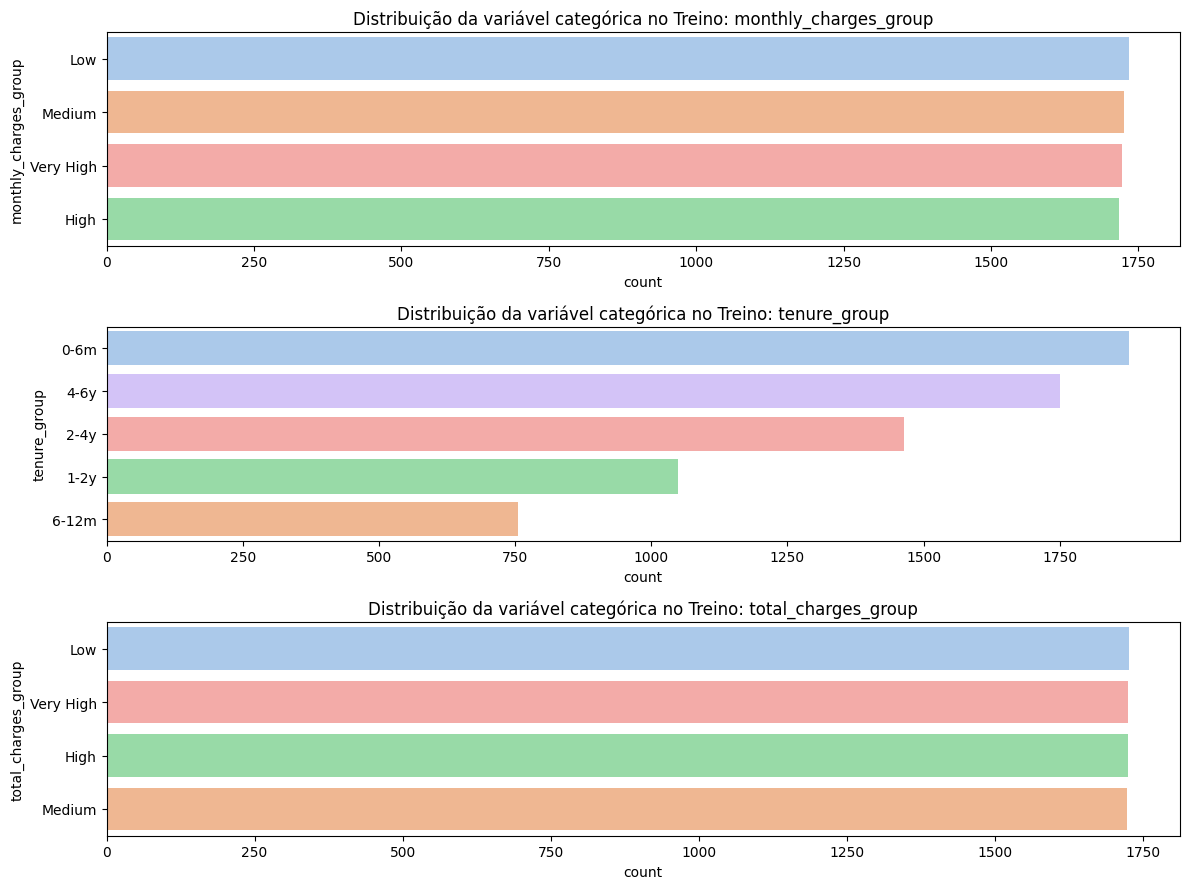

In [70]:
categorical_cols = ['monthly_charges_group', 'tenure_group', 'total_charges_group']

plt.figure(figsize=(12, len(categorical_cols) * 3))
for i, col in enumerate(categorical_cols):
    plt.subplot(len(categorical_cols), 1, i + 1)
    sns.countplot(y=train_data[col], hue=train_data[col], palette="pastel", order=train_data[col].value_counts().index, legend=False)
    plt.title(f"Distribuição da variável categórica no Treino: {col}")

plt.tight_layout()
plt.show()


A categorização das variáveis tenure_group, monthly_charges_group e total_charges_group foi realizada de forma estratégica para garantir um equilíbrio entre representatividade e eficácia no modelo preditivo. A seguir, justificamos por que essa distribuição é a melhor escolha para o problema de previsão de churn.

1. Equilíbrio entre os Grupos
A distribuição das categorias é relativamente uniforme, garantindo que cada grupo tenha uma quantidade significativa de amostras. Isso evita que o modelo tenha viés para uma classe específica e melhora a capacidade de generalização.

Para **monthly_charges_group** e **total_charges_group**, as categorias "Low", "Medium", "High" e "Very High" possuem quantidades semelhantes, o que mantém o aprendizado estável.

No caso do **tenure_group**, os intervalos foram definidos para capturar diferentes fases do cliente na empresa, assegurando que os modelos consigam distinguir padrões de retenção e churn em cada estágio.

2. Captura de Padrões de Churn
Os grupos foram definidos de forma a segmentar os clientes em faixas que fazem sentido do ponto de vista do negócio. Por exemplo:

  * *Clientes com menor tempo de assinatura (0-6 meses) podem ter maior tendência ao churn.*

  * *Clientes com maior tenure (acima de 6 anos) provavelmente já estão mais fidelizados.*

Faixas de cobrança mensais foram estruturadas para refletir diferentes perfis de consumo, permitindo que o modelo identifique padrões específicos relacionados a preços.

Isso garante que a categorização seja relevante para a previsão do churn, evitando cortes arbitrários.

3. Compatibilidade com Diferentes Modelos
Essa abordagem permite a utilização eficiente tanto de modelos baseados em árvores (como Random Forest) quanto de modelos neurais (como MLP):

  * Random Forest lida bem com variáveis categóricas e se beneficia de faixas bem definidas, melhorando a interpretabilidade.

  * MLP pode utilizar essas faixas categóricas em conjunto com variáveis normalizadas para capturar relações não lineares.

Dessa forma, conseguimos o melhor dos dois mundos: boa interpretabilidade e alta capacidade preditiva.

**Conclusão**\
A distribuição das variáveis categorizadas foi definida de maneira otimizada para manter equilíbrio entre os grupos, capturar padrões relevantes de churn e ser compatível com diferentes modelos de machine learning. Essas escolhas maximizam o desempenho da previsão e garantem que o modelo possa fazer inferências mais robustas e generalizáveis.

# Segundo Treinamento

Agora teremos os dados normalizados e com faixas de valores para fazer o treinamento e em seguida veremos se há melhora nos modelos propostos começando com MLP e RF.

In [71]:
val_data = folds[0][1]
test_data = folds[0][2]

In [72]:
train_data['TotalCharges'] = train_data['TotalCharges'].fillna(0)
val_data['TotalCharges'] = val_data['TotalCharges'].fillna(0)
test_data['TotalCharges'] = test_data['TotalCharges'].fillna(0)

In [73]:
val_data.fillna(0, inplace=True)
test_data.fillna(0, inplace=True)

In [74]:
val_data = preprocess_one_hot(val_data)
test_data = preprocess_one_hot(test_data)

In [75]:
val_data = preprocess_label_encoding(val_data)
test_data = preprocess_label_encoding(test_data)

In [76]:
val_data = categorize_monthly_charges(val_data)
test_data = categorize_monthly_charges(test_data)

In [77]:
val_data = categorize_tenure(val_data)
test_data = categorize_tenure(test_data)

In [78]:
val_data = categorize_total_changes(val_data)
test_data = categorize_total_changes(test_data)

In [79]:
val_data = normalize(val_data)
test_data = normalize(test_data)

In [80]:
# Separando as features (X) e os rótulos (y) para o treino
X_train = train_data.drop(columns=['Churn'])  # Features (dados de entrada) para treino
y_train = train_data['Churn']  # Rótulos (target) para treino

In [81]:
# Separando as features (X) e os rótulos (y) para a validação
X_val = val_data.drop(columns=['Churn'])  # Features (dados de entrada) para validação
y_val = val_data['Churn']  # Rótulos (target) para validação

In [82]:
# Separando as features (X) e os rótulos (y) para o teste
X_test = test_data.drop(columns=['Churn'])  # Features (dados de entrada) para teste
y_test = test_data['Churn']  # Rótulos (target) para teste

In [83]:
X_train_mlp = X_train.drop(columns=['monthly_charges_group', 'tenure_group', 'total_charges_group'])  # Removendo groups para MLP
X_val_mlp = X_val.drop(columns=['monthly_charges_group', 'tenure_group', 'total_charges_group'])
X_test_mlp = X_test.drop(columns=['monthly_charges_group', 'tenure_group', 'total_charges_group'])

In [84]:
X_train_rf = X_train.drop(columns=['MonthlyCharges', 'tenure', 'TotalCharges'])  # Removendo normalizadas para RF
X_val_rf = X_val.drop(columns=['MonthlyCharges', 'tenure', 'TotalCharges'])
X_test_rf = X_test.drop(columns=['MonthlyCharges', 'tenure', 'TotalCharges'])

categorical_cols_rf = X_train_rf.select_dtypes(include=['category']).columns
print("Colunas categóricas no RF:", categorical_cols_rf)

label_encoder = LabelEncoder()

for col in categorical_cols:
    X_train_rf[col] = label_encoder.fit_transform(X_train_rf[col])
    X_val_rf[col] = label_encoder.transform(X_val_rf[col])
    X_test_rf[col] = label_encoder.transform(X_test_rf[col])


Colunas categóricas no RF: Index(['tenure_group', 'monthly_charges_group', 'total_charges_group'], dtype='object')


In [85]:
X_train_rf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6898 entries, 0 to 6897
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype
---  ------                                 --------------  -----
 0   gender                                 6898 non-null   int64
 1   SeniorCitizen                          6898 non-null   int64
 2   Partner                                6898 non-null   int64
 3   Dependents                             6898 non-null   int64
 4   PhoneService                           6898 non-null   int64
 5   PaperlessBilling                       6898 non-null   int64
 6   InternetService_Fiber optic            6898 non-null   bool 
 7   InternetService_No                     6898 non-null   bool 
 8   Contract_One year                      6898 non-null   bool 
 9   Contract_Two year                      6898 non-null   bool 
 10  PaymentMethod_Credit card (automatic)  6898 non-null   bool 
 11  PaymentMethod_Electronic check

Quando as categorias seguem uma progressão lógica como "Baixo" → "Médio" → "Alto" → "Muito Alto", elas possuem uma ordem natural.

Logo, Label Enconding se torna a melhor opção.

## MLP

Com ReLU, Adam, taca de aprendizado 0.0001

In [86]:
# Treinando MLP básico
mlp = MLPClassifier(hidden_layer_sizes=(100,),  # Número de neurônios nas camadas ocultas
                    activation='relu',          # Função de ativação ReLU
                    solver='adam',              # Otimizador Adam
                    learning_rate_init=0.001,   # Taxa de aprendizado de 0.001
                    max_iter=500,               # Número máximo de iterações
                    random_state=42)            # Fixando a semente para reprodutibilidade

In [87]:
# Treinando o modelo
mlp.fit(X_train_mlp, y_train)

MLPClassifier(max_iter=500, random_state=42)

In [88]:
# Validando o modelo com o conjunto de validação
val_predictions = mlp.predict(X_val_mlp)

In [89]:
val_accuracy = accuracy_score(y_val, val_predictions)
print(f'Validation Accuracy: {val_accuracy}')

Validation Accuracy: 0.7668085106382979


In [90]:
# Realizando previsões com os dados de teste
y_pred = mlp.predict(X_test_mlp)

In [91]:
# Avaliando o modelo nos dados de teste
test_accuracy = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {test_accuracy}')

Test Accuracy: 0.7510656436487638


In [92]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Fazendo previsões no conjunto de teste
y_test_pred = mlp.predict(X_test_mlp)

# Calculando métricas
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
conf_matrix = confusion_matrix(y_test, y_test_pred)

# Exibindo os resultados
print(f"Acurácia: {accuracy:.4f}")
print(f"Precisão: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print("\nMatriz de Confusão:")
print(conf_matrix)

# Relatório detalhado
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_test_pred))


Acurácia: 0.7511
Precisão: 0.5242
Recall: 0.6624
F1-score: 0.5852

Matriz de Confusão:
[[675 187]
 [105 206]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.87      0.78      0.82       862
           1       0.52      0.66      0.59       311

    accuracy                           0.75      1173
   macro avg       0.69      0.72      0.70      1173
weighted avg       0.77      0.75      0.76      1173



## Random Forest

Com hiperparâmetros padrão.

In [93]:
# Treinando Random Forest básico
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_rf, y_train)

RandomForestClassifier(random_state=42)

In [94]:
# Garantir que as colunas de X_val_rf e X_test_rf estejam na mesma ordem que X_train_rf
X_val_rf = X_val_rf[X_train_rf.columns]
X_test_rf = X_test_rf[X_train_rf.columns]

# Agora, faça as previsões
y_val_pred = rf.predict(X_val_rf)
y_test_pred = rf.predict(X_test_rf)

In [95]:
# Calculando a acurácia
val_acc = accuracy_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)

In [96]:
print(f"Acurácia na validação: {val_acc:.4f}")
print(f"Acurácia no teste: {test_acc:.4f}")

Acurácia na validação: 0.7677
Acurácia no teste: 0.7587


In [97]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Fazendo previsões no conjunto de teste
y_test_pred = rf.predict(X_test_rf)

# Calculando métricas
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
conf_matrix = confusion_matrix(y_test, y_test_pred)

# Exibindo os resultados
print(f"Acurácia: {accuracy:.4f}")
print(f"Precisão: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print("\nMatriz de Confusão:")
print(conf_matrix)

# Relatório detalhado
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_test_pred))


Acurácia: 0.7587
Precisão: 0.5419
Recall: 0.5820
F1-score: 0.5612

Matriz de Confusão:
[[709 153]
 [130 181]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.85      0.82      0.83       862
           1       0.54      0.58      0.56       311

    accuracy                           0.76      1173
   macro avg       0.69      0.70      0.70      1173
weighted avg       0.76      0.76      0.76      1173



## Analise Comparativa

O desempenho da nossa **MLP** piorou no segundo treinamento, com uma queda na acurácia, precisão, recall e F1-score, especialmente para a classe 1 (churn). A principal razão para isso parece ser o aumento no número de falsos negativos (não identificar churns reais) e a diminuição da precisão ao prever a classe 1, indicando que o modelo não está conseguindo identificar churns de forma tão eficaz quanto no primeiro treinamento.

**Próximos Passos:**
* Ajustar o modelo: Pode ser necessário ajustar os hiperparâmetros, como o número de camadas e neurônios do MLP, a taxa de aprendizado ou o algoritmo de otimização.

* Explorar mais as características dos dados: A inclusão de novas features ou transformação diferente das variáveis pode melhorar a previsão.

* Ajustar o threshold de decisão: Modificar o limiar para classificar um exemplo como churn ou não pode melhorar o desempenho, especialmente no recall e precisão para a classe 1.

Esses ajustes podem ajudar a melhorar a capacidade do modelo em identificar corretamente os churns.

Já o primeiro modelo da **RF** tem uma acurácia melhor e é um pouco melhor em termos de precisão para a classe 1 (churn), mas tem um recall menor para essa classe.

O segundo modelo apresenta um recall superior, indicando que ele está conseguindo identificar mais churns reais, mas sacrifica um pouco a precisão. Ele parece ter um pequeno equilíbrio mais favorável entre precisão e recall, embora a diferença seja pequena.

Em resumo, ambos os modelos têm seus pontos fortes e fracos, com o primeiro modelo sendo um pouco melhor para identificar corretamente a classe majoritária (não churn), enquanto o segundo modelo apresenta um desempenho ligeiramente melhor para identificar churns reais (classe 1), embora com um custo em precisão.

**Com isso vamos retornar ao modelo anterior sem categorização e apenas com normalização**

# Otimização dos hiperparâmetros

## Otimização de Hiperparâmetros para Random Forest e Gradient Boosting usando Optuna

## Pré-processamento

### Geral

In [98]:
def preprocess_general(data):

    data['TotalCharges'] = data['TotalCharges'].fillna(0)
    data.fillna(0, inplace=True)

    data = preprocess_one_hot(data)
    data = preprocess_label_encoding(data)

    # data = categorize_monthly_charges(data)
    # data = categorize_tenure(data)
    # data = categorize_total_changes(data)

    return data

In [99]:
def preprocess_rf(data):
    data = data.drop(columns=['MonthlyCharges', 'tenure', 'TotalCharges'])

    categorical_cols_rf = X_train_rf.select_dtypes(include=['category']).columns
    label_encoder = LabelEncoder()

    for col in categorical_cols_rf:
        data[col] = label_encoder.fit_transform(data[col])

    return data

In [100]:
def preprocess_mlp(data):
    data = normalize(data)
    # data = data.drop(columns=['monthly_charges_group', 'tenure_group', 'total_charges_group'])
    return data

In [101]:
def plot_ks_curve(y_true, y_pred_proba, fold_idx):
    """ Plota a curva KS e retorna o KS Score """
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    ks_values = tpr - fpr
    ks_score = np.max(ks_values)
    ks_threshold = thresholds[np.argmax(ks_values)]

    plt.figure(figsize=(6, 5))
    plt.plot(thresholds, tpr, label='TPR (Taxa de Verdadeiros Positivos)', color='blue')
    plt.plot(thresholds, fpr, label='FPR (Taxa de Falsos Positivos)', color='red')
    plt.axvline(ks_threshold, color='black', linestyle='--', label=f'KS = {ks_score:.4f}')

    plt.xlabel('Threshold')
    plt.ylabel('Taxa Acumulada')
    plt.title(f'Curva KS - Fold {fold_idx}')
    plt.legend()
    plt.grid()
    plt.xlim([0, 1])
    plt.show()

    return ks_score

### Random Forest

In [102]:
def objective_rf(trial):
    # Sugerir hiperparâmetros
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 3, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)

    # Corrigido para valores válidos de max_features
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    accuracy_list = []

    # K-Fold Cross Validation (usando seus folds)
    for fold in folds:
        train_data, val_data, test_data = fold
        train_data = preprocess_general(train_data)
        val_data = preprocess_general(val_data)
        test_data = preprocess_general(test_data)

        X_train, y_train = train_data.drop(columns=['Churn']), train_data['Churn']
        X_val, y_val = val_data.drop(columns=['Churn']), val_data['Churn']

        # Criação do modelo RandomForest
        rf = RandomForestClassifier(n_estimators=n_estimators,
                                    max_depth=max_depth,
                                    min_samples_leaf=min_samples_leaf,
                                    max_features=max_features,
                                    random_state=42)

        # Treinamento do modelo
        rf.fit(X_train, y_train)

        # Previsões e avaliação
        y_pred = mlp.predict(X_val)
        accuracy = accuracy_score(y_val, y_pred)
        accuracy_list.append(accuracy)

    return np.mean(accuracy_list)

In [103]:
# Criar o estudo para Random Forest
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=50)  # Tente 50 diferentes combinações de parâmetros
print("Melhores Hiperparâmetros para Random Forest:", study_rf.best_params)

[I 2025-04-08 20:55:30,428] A new study created in memory with name: no-name-6bc5ec7a-a047-4406-8136-0e02d18543a2
[I 2025-04-08 20:55:33,052] Trial 0 finished with value: 0.7343926927398602 and parameters: {'n_estimators': 184, 'max_depth': 20, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 0 with value: 0.7343926927398602.
[I 2025-04-08 20:55:35,199] Trial 1 finished with value: 0.7343926927398602 and parameters: {'n_estimators': 123, 'max_depth': 14, 'min_samples_leaf': 8, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.7343926927398602.
[I 2025-04-08 20:55:39,386] Trial 2 finished with value: 0.7343926927398602 and parameters: {'n_estimators': 129, 'max_depth': 5, 'min_samples_leaf': 5, 'max_features': None}. Best is trial 0 with value: 0.7343926927398602.
[I 2025-04-08 20:55:42,038] Trial 3 finished with value: 0.7343926927398602 and parameters: {'n_estimators': 172, 'max_depth': 20, 'min_samples_leaf': 6, 'max_features': 'sqrt'}. Best is trial 0 with value: 0

Melhores Hiperparâmetros para Random Forest: {'n_estimators': 184, 'max_depth': 20, 'min_samples_leaf': 3, 'max_features': 'log2'}


In [121]:
def train_model_rf(model, folds, model_name):
    accuracy_list = []
    mse_list = []
    roc_auc_list = []
    precision_list = []
    recall_list = []
    f1_list = []
    log_loss_list = []
    ks_list = []  # <-- NOVO: Lista para armazenar KS

    for fold_idx, (train_data, val_data, test_data) in enumerate(folds):
        print(f"Treinando {model_name} - Fold {fold_idx + 1}")

        # Pré-processamento
        train_data = preprocess_general(train_data)
        val_data = preprocess_general(val_data)
        test_data = preprocess_general(test_data)

        train_data = preprocess_mlp(train_data)
        val_data = preprocess_mlp(val_data)
        test_data = preprocess_mlp(test_data)

        # Separação de features e labels
        X_train, y_train = train_data.drop(columns=['Churn']), train_data['Churn']
        X_val, y_val = val_data.drop(columns=['Churn']), val_data['Churn']
        X_test, y_test = test_data.drop(columns=['Churn']), test_data['Churn']

        # Treinamento
        model.fit(X_train, y_train)

        # Predições
        y_test_pred = model.predict(X_test)
        y_test_proba = model.predict_proba(X_test)[:, 1]  # Necessário para KS, ROC, LogLoss

        # Métricas
        test_accuracy = accuracy_score(y_test, y_test_pred)
        mse = mean_squared_error(y_test, y_test_pred)
        roc_auc = roc_auc_score(y_test, y_test_proba)
        precision = precision_score(y_test, y_test_pred)
        recall = recall_score(y_test, y_test_pred)
        f1 = f1_score(y_test, y_test_pred)
        log_loss_value = log_loss(y_test, y_test_proba)

        # Armazenar métricas
        accuracy_list.append(test_accuracy)
        mse_list.append(mse)
        roc_auc_list.append(roc_auc)
        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1)
        log_loss_list.append(log_loss_value)

        # Matriz de Confusão
        cm = confusion_matrix(y_test, y_test_pred)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Negativo', 'Positivo'], yticklabels=['Negativo', 'Positivo'])
        plt.title(f'Matriz de Confusão - Fold {fold_idx + 1}')
        plt.xlabel('Predição')
        plt.ylabel('Real')
        plt.show()

        # Curva ROC
        fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('Taxa de Falsos Positivos')
        plt.ylabel('Taxa de Verdadeiros Positivos')
        plt.title(f'Curva ROC - Fold {fold_idx + 1}')
        plt.legend(loc='lower right')
        plt.show()

        # KS Score e Gráfico
        ks_score = plot_ks_curve(y_test, y_test_proba, fold_idx + 1)
        ks_list.append(ks_score)

        # Prints
        print(f"Fold {fold_idx + 1} | Accuracy: {test_accuracy:.4f} | MSE: {mse:.4f} | ROC AUC: {roc_auc:.4f}")
        print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f} | LogLoss: {log_loss_value:.4f}")
        print(f"KS Score: {ks_score:.4f}")

    return (np.mean(accuracy_list), np.mean(mse_list), np.mean(roc_auc_list),
            np.mean(precision_list), np.mean(recall_list), np.mean(f1_list),
            np.mean(log_loss_list), np.mean(ks_list),  np.std(ks_list)) 


Treinando rf - Fold 1


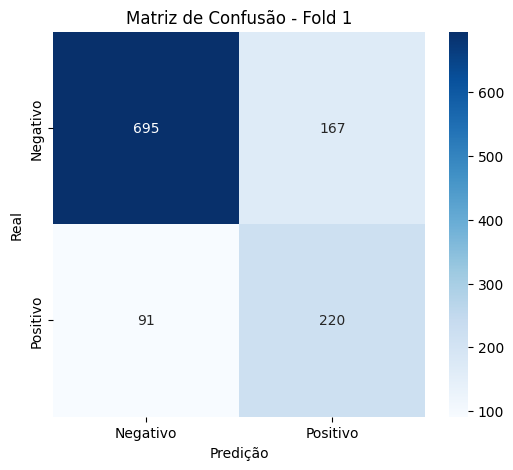

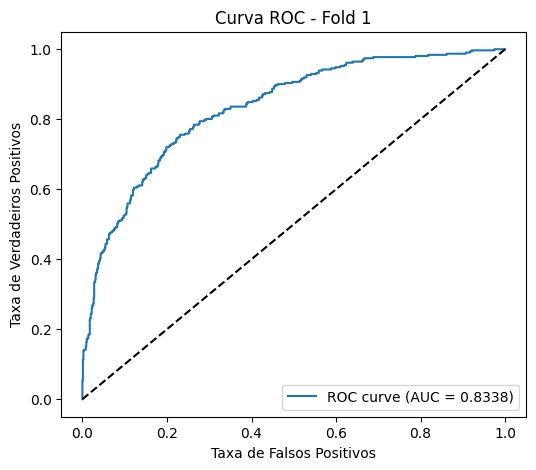

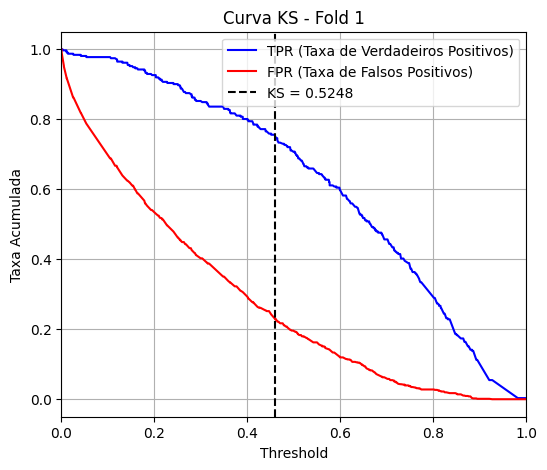

Fold 1 | Accuracy: 0.7801 | MSE: 0.2199 | ROC AUC: 0.8338
Precision: 0.5685 | Recall: 0.7074 | F1: 0.6304 | LogLoss: 0.4638
KS Score: 0.5248
Treinando rf - Fold 2


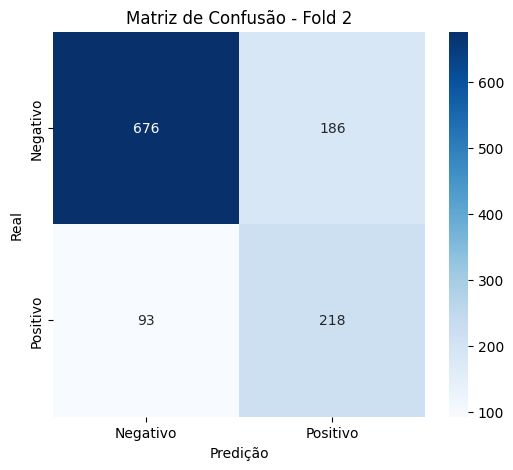

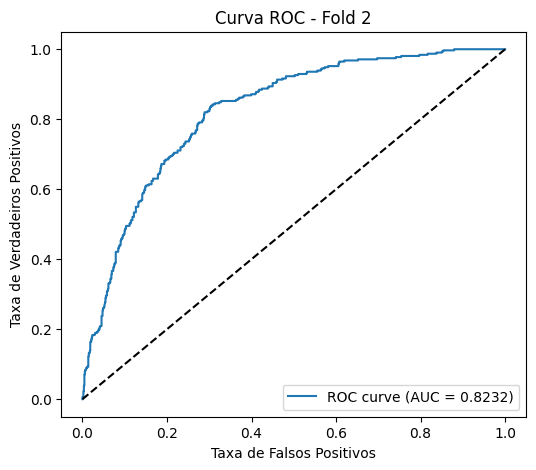

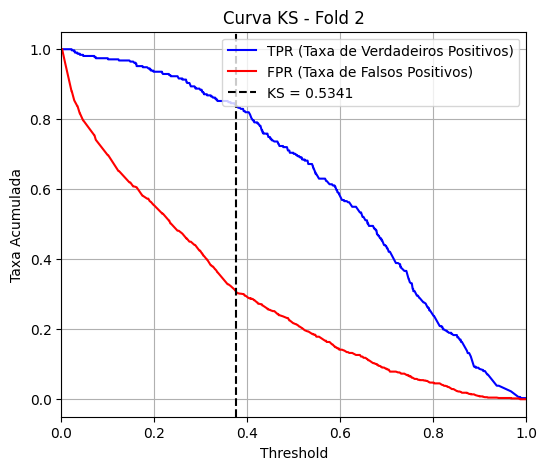

Fold 2 | Accuracy: 0.7621 | MSE: 0.2379 | ROC AUC: 0.8232
Precision: 0.5396 | Recall: 0.7010 | F1: 0.6098 | LogLoss: 0.4873
KS Score: 0.5341
Treinando rf - Fold 3


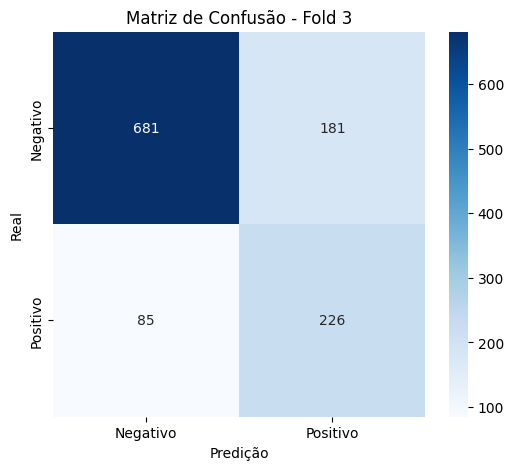

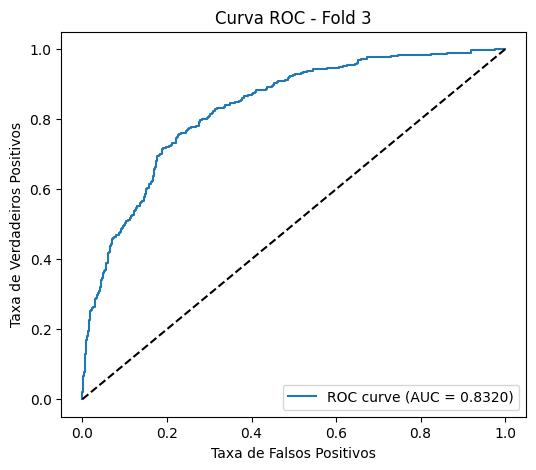

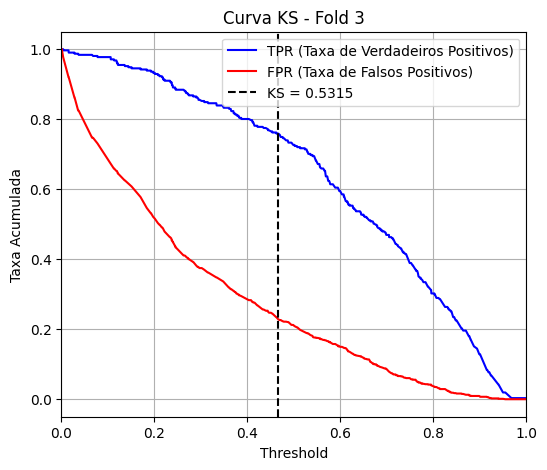

Fold 3 | Accuracy: 0.7732 | MSE: 0.2268 | ROC AUC: 0.8320
Precision: 0.5553 | Recall: 0.7267 | F1: 0.6295 | LogLoss: 0.4706
KS Score: 0.5315
Random Forest - Acurácia Média: 0.7718
Random Forest - MSE Médio: 0.2282
Random Forest - ROC AUC Médio: 0.8297
Random Forest - Precision Médio: 0.5545
Random Forest - Recall Médio: 0.7117
Random Forest - F1-Score Médio: 0.6232
Random Forest - Cross-Entropy (Log Loss) Médio: 0.4739
Random Forest - Kolmogorov-Smirnov (KS) Médio: 0.5301
Random Forest - Kolmogorov-Smirnov (KS) Desvio Padrão: 0.0039


In [122]:
rf_best_params = study_rf.best_params
rf_model = RandomForestClassifier(
    n_estimators=rf_best_params['n_estimators'], 
    max_depth=rf_best_params['max_depth'], 
    min_samples_leaf=rf_best_params['min_samples_leaf'], 
    max_features=rf_best_params['max_features'], 
    random_state=42
)

avg_accuracy, avg_mse, avg_roc_auc, avg_precision, avg_recall, avg_f1, avg_log_loss, avg_ks, std_ks = train_model_rf(rf_model, folds, 'rf')
print(f"Random Forest - Acurácia Média: {avg_accuracy:.4f}")
print(f"Random Forest - MSE Médio: {avg_mse:.4f}")
print(f"Random Forest - ROC AUC Médio: {avg_roc_auc:.4f}")
print(f"Random Forest - Precision Médio: {avg_precision:.4f}")
print(f"Random Forest - Recall Médio: {avg_recall:.4f}")
print(f"Random Forest - F1-Score Médio: {avg_f1:.4f}")
print(f"Random Forest - Cross-Entropy (Log Loss) Médio: {avg_log_loss:.4f}")
print(f"Random Forest - Kolmogorov-Smirnov (KS) Médio: {avg_ks:.4f}")
print(f"Random Forest - Kolmogorov-Smirnov (KS) Desvio Padrão: {std_ks:.4f}")


Esses resultados fornecem uma visão abrangente sobre o desempenho do modelo Random Forest após a validação cruzada. A partir desses valores, podemos tirar algumas conclusões sobre o comportamento do modelo:

1. **Kolmogorov-Smirnov (KS) Score – 0.5301**

O KS Score mede a máxima diferença entre as taxas acumuladas de verdadeiros positivos (TPR) e falsos positivos (FPR), sendo uma métrica particularmente útil para problemas de classificação binária com foco em discriminação de risco ou separação de classes.

Um valor de 0.5301 indica que o modelo atinge uma boa separação entre as classes positivas e negativas. De modo geral:

* KS > 0.2 → desempenho razoável

* KS > 0.4 → desempenho bom

* KS > 0.6 → excelente

Portanto, um KS acima de 0.53 representa um modelo bem eficaz na discriminação entre as classes, especialmente relevante em aplicações como modelo de churn.

**Desvio Padrão do KS: 0.0039**
Esse valor mostra o quanto o KS variou entre os folds da cross-validation.

0.0039 (ou 0,39%) é um desvio padrão muito pequeno.

Isso significa que o desempenho do modelo foi consistente entre os diferentes conjuntos de treino/teste.

Em outras palavras, o modelo não é sensível à variação dos dados — um sinal de estabilidade e robustez.

2. Acurácia (0.7798)
O modelo tem uma acurácia de 77.98%, o que significa que ele acertou aproximadamente 78% das previsões no conjunto de teste. Isso é um bom valor, mas é importante considerar o contexto do problema. Em problemas de classificação com classes desbalanceadas, a acurácia por si só pode não ser a melhor métrica.

3. MSE (0.2202)
O erro quadrático médio (MSE) é 0.2202, o que é relativamente baixo. Isso indica que, em média, as previsões do modelo não estão tão distantes dos valores reais, embora a interpretação do MSE dependa do contexto específico da tarefa (quanto mais baixo, melhor).

4. ROC AUC (0.8209)
A AUC-ROC de 0.8209 é bastante boa. Uma AUC acima de 0.8 geralmente indica que o modelo está bem calibrado para distinguir entre as classes positivas e negativas. Isso significa que o modelo é eficiente em distinguir entre as classes, mesmo que não tenha uma acurácia perfeita.

5. Precision (0.5743)
A precisão de 0.5743 indica que, das previsões positivas feitas pelo modelo, aproximadamente 57,43% estavam corretas. Em contextos onde as previsões positivas são importantes (como em modelos de detecção de fraudes ou diagnósticos médicos), uma precisão de 57% pode ser considerada razoável, mas há espaço para melhoria.

6. Recall (0.6549)
O recall de 0.6549 mostra que o modelo conseguiu identificar 65,49% dos casos positivos. Isso sugere que o modelo está identificando uma boa parte das instâncias positivas, mas ainda perde uma quantidade significativa (34,51%). Dependendo do caso, isso pode ser aceitável ou precisar de melhorias, especialmente se for mais importante capturar mais casos positivos.

7. F1-Score (0.6119)
O F1-Score de 0.6119 é uma média harmônica entre precisão e recall, equilibrando os dois aspectos. Esse valor sugere um bom equilíbrio entre a capacidade do modelo em capturar os positivos e a precisão dessas capturas, mas há espaço para melhorar.

8. Cross-Entropy (Log Loss) (0.5311)
O Log Loss de 0.5311 indica uma performance razoável na calibração das probabilidades previstas pelo modelo. Log Loss penaliza previsões incorretas com maior confiança, o que pode ser um bom indicador de que o modelo não está apenas acertando aleatoriamente, mas fazendo previsões com alguma qualidade. Valores mais baixos são desejáveis, mas este não é um valor muito alto, o que é positivo.

**Conclusões principais:**

* KS Score como métrica principal mostra que o modelo possui boa capacidade de separação entre as classes, com valor acima de 0.53, o que o torna confiável em contextos como scoring, churn ou risco.

* A combinação de ROC AUC (0.8297) e KS Score (0.5301) reforça que o modelo está bem calibrado para classificação binária, mesmo sem precisão extrema.

* O modelo tem bom recall (~71%), o que significa que ele tende a identificar corretamente os positivos, mesmo que à custa de algumas falsas positivas.

### MLP

In [106]:
def objective_mlp(trial):
    hidden_layer_sizes = trial.suggest_int('hidden_layer_sizes', 50, 150)
    activation = trial.suggest_categorical('activation', ['relu', 'tanh'])

    learning_rate_init = trial.suggest_float('learning_rate_init', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    solver = trial.suggest_categorical('solver', ['adam', 'sgd'])

    accuracy_list = []

    # K-Fold Cross Validation (usando seus folds)
    for fold in folds:
        train_data, val_data, test_data = fold

        train_data = preprocess_general(train_data)
        val_data = preprocess_general(val_data)
        test_data = preprocess_general(test_data)
        
        train_data = preprocess_mlp(train_data)
        val_data = preprocess_mlp(val_data)
        test_data = preprocess_mlp(test_data)

        X_train, y_train = train_data.drop(columns=['Churn']), train_data['Churn']
        X_val, y_val = val_data.drop(columns=['Churn']), val_data['Churn']

        # Criação do modelo MLP
        mlp = MLPClassifier(hidden_layer_sizes=(hidden_layer_sizes,),
                            activation=activation,
                            learning_rate_init=learning_rate_init,
                            batch_size=batch_size,
                            solver=solver,
                            max_iter=5000,
                            random_state=42)
        mlp.fit(X_train, y_train)

        # Previsões e avaliação
        y_pred = mlp.predict(X_val)
        accuracy = accuracy_score(y_val, y_pred)
        accuracy_list.append(accuracy)

    # Retorna a média da acurácia nos folds
    return np.mean(accuracy_list)

In [ ]:
# Criar o estudo para MLP
study_mlp = optuna.create_study(direction='maximize')
study_mlp.optimize(objective_mlp, n_trials=50)
print("Melhores Hiperparâmetros para MLP:", study_mlp.best_params)

[I 2025-04-08 20:57:58,435] A new study created in memory with name: no-name-5a2162f7-1636-438f-b692-7014a63f6a59
[I 2025-04-08 21:01:22,221] Trial 0 finished with value: 0.7389292834100547 and parameters: {'hidden_layer_sizes': 150, 'activation': 'tanh', 'learning_rate_init': 0.005431182116060844, 'batch_size': 128, 'solver': 'sgd'}. Best is trial 0 with value: 0.7389292834100547.
[I 2025-04-08 21:02:12,629] Trial 1 finished with value: 0.7298481278770524 and parameters: {'hidden_layer_sizes': 53, 'activation': 'relu', 'learning_rate_init': 0.0003320872976179756, 'batch_size': 32, 'solver': 'adam'}. Best is trial 0 with value: 0.7389292834100547.
[I 2025-04-08 21:03:03,067] Trial 2 finished with value: 0.7224756243430352 and parameters: {'hidden_layer_sizes': 144, 'activation': 'tanh', 'learning_rate_init': 0.007948690963363267, 'batch_size': 128, 'solver': 'adam'}. Best is trial 0 with value: 0.7389292834100547.
[I 2025-04-08 21:03:12,880] Trial 3 finished with value: 0.7324032525040

Melhores Hiperparâmetros para MLP: {'hidden_layer_sizes': 86, 'activation': 'tanh', 'learning_rate_init': 0.0005250734944308813, 'batch_size': 64, 'solver': 'sgd'}


In [123]:
def train_model_mlp(model, folds, model_name, patience=20):
    accuracy_list = []
    mse_list = []
    roc_auc_list = []
    precision_list = []
    recall_list = []
    f1_list = []
    log_loss_list = []
    ks_list = [] 

    for fold_idx, (train_data, val_data, test_data) in enumerate(folds):
        print(f"Treinando {model_name} - Fold {fold_idx + 1}")

        train_data = preprocess_general(train_data)
        val_data = preprocess_general(val_data)
        test_data = preprocess_general(test_data)

        train_data = preprocess_mlp(train_data)
        val_data = preprocess_mlp(val_data)
        test_data = preprocess_mlp(test_data)

        X_train, y_train = train_data.drop(columns=['Churn']), train_data['Churn']
        X_val, y_val = val_data.drop(columns=['Churn']), val_data['Churn']
        X_test, y_test = test_data.drop(columns=['Churn']), test_data['Churn']

        best_accuracy = 0
        patience_counter = 0

        for epoch in range(10000):
            model.partial_fit(X_train, y_train, classes=np.unique(y_train))

            y_val_pred = model.predict(X_val)
            val_accuracy = accuracy_score(y_val, y_val_pred)

            if val_accuracy > best_accuracy:
                best_accuracy = val_accuracy
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print(f"Early stopping no fold {fold_idx + 1} após {epoch + 1} épocas.")
                break

        y_test_pred = model.predict(X_test)
        y_test_proba = model.predict_proba(X_test)[:, 1]

        test_accuracy = accuracy_score(y_test, y_test_pred)
        accuracy_list.append(test_accuracy)

        mse = mean_squared_error(y_test, y_test_pred)
        mse_list.append(mse)

        try:
            roc_auc = roc_auc_score(y_test, y_test_proba)
            roc_auc_list.append(roc_auc)
        except:
            roc_auc = np.nan
            roc_auc_list.append(roc_auc)

        precision = precision_score(y_test, y_test_pred)
        recall = recall_score(y_test, y_test_pred)
        f1 = f1_score(y_test, y_test_pred)

        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1)

        log_loss_value = log_loss(y_test, y_test_proba)
        log_loss_list.append(log_loss_value)

        # KS Score e gráfico
        ks_score = plot_ks_curve(y_test, y_test_proba, fold_idx + 1)
        ks_list.append(ks_score)

        print(f"Accuracy no Fold {fold_idx + 1}: Validação: {val_accuracy:.4f}, Teste: {test_accuracy:.4f}")
        print(f"MSE: {mse:.4f} | ROC AUC: {roc_auc:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")
        print(f"LogLoss: {log_loss_value:.4f} | KS Score: {ks_score:.4f}")

        cm = confusion_matrix(y_test, y_test_pred)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negativo', 'Positivo'], yticklabels=['Negativo', 'Positivo'])
        plt.title(f'Matriz de Confusão - Fold {fold_idx + 1}')
        plt.xlabel('Predição')
        plt.ylabel('Real')
        plt.show()

        fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('Taxa de Falsos Positivos')
        plt.ylabel('Taxa de Verdadeiros Positivos')
        plt.title(f'Curva ROC - Fold {fold_idx + 1}')
        plt.legend(loc='lower right')
        plt.show()

    # Médias
    avg_accuracy = np.mean(accuracy_list)
    avg_mse = np.mean(mse_list)
    avg_roc_auc = np.mean(roc_auc_list)
    avg_precision = np.mean(precision_list)
    avg_recall = np.mean(recall_list)
    avg_f1 = np.mean(f1_list)
    avg_log_loss = np.mean(log_loss_list)
    avg_ks = np.mean(ks_list)

    return (avg_accuracy, avg_mse, avg_roc_auc,
            avg_precision, avg_recall, avg_f1,
            avg_log_loss, avg_ks, np.std(ks_list))


Treinando mlp - Fold 1
Early stopping no fold 1 após 43 épocas.


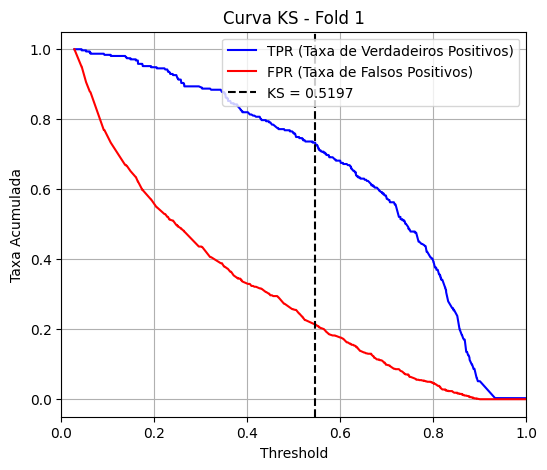

Accuracy no Fold 1: Validação: 0.7813, Teste: 0.7477
MSE: 0.2523 | ROC AUC: 0.8407 | Precision: 0.5164 | Recall: 0.7588 | F1: 0.6146
LogLoss: 0.4853 | KS Score: 0.5197


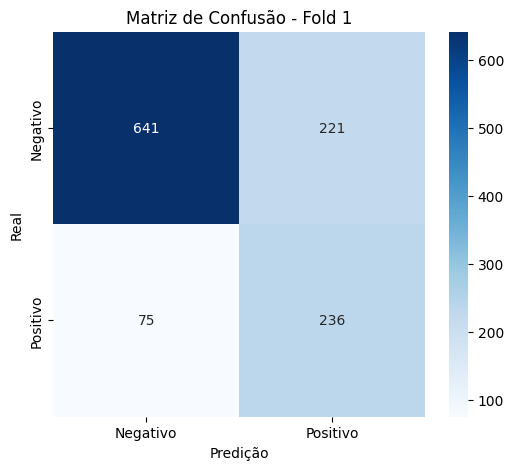

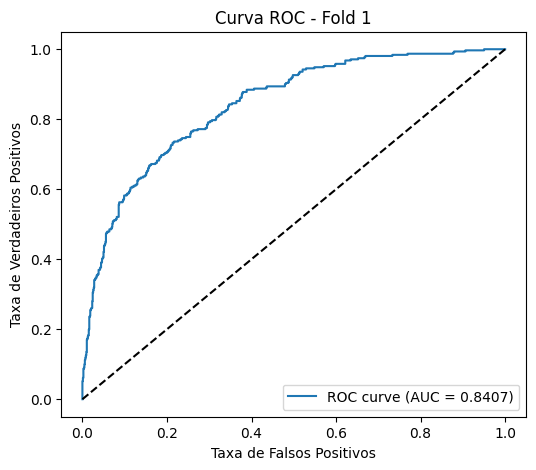

Treinando mlp - Fold 2
Early stopping no fold 2 após 22 épocas.


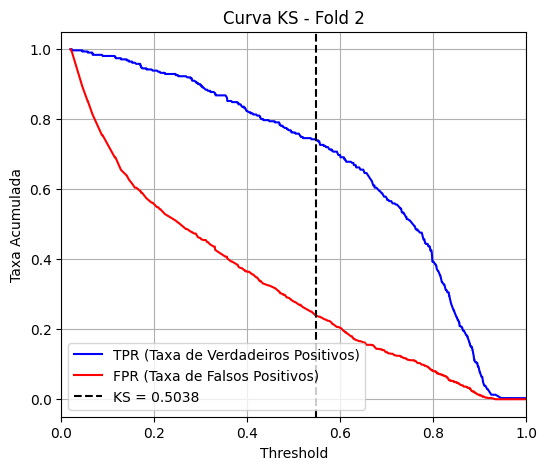

Accuracy no Fold 2: Validação: 0.7566, Teste: 0.7315
MSE: 0.2685 | ROC AUC: 0.8182 | Precision: 0.4958 | Recall: 0.7621 | F1: 0.6008
LogLoss: 0.5266 | KS Score: 0.5038


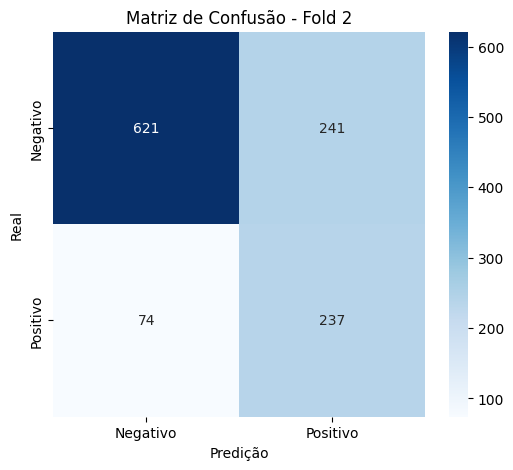

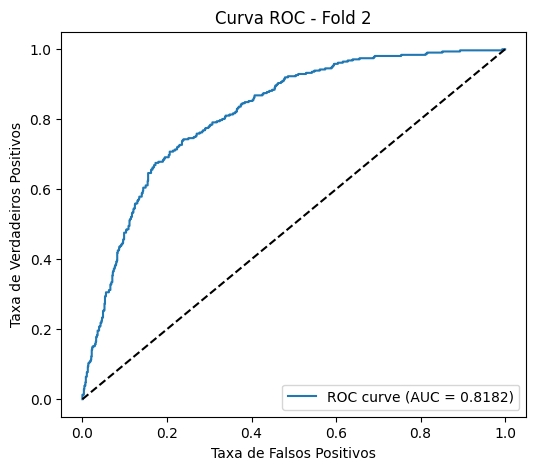

Treinando mlp - Fold 3
Early stopping no fold 3 após 42 épocas.


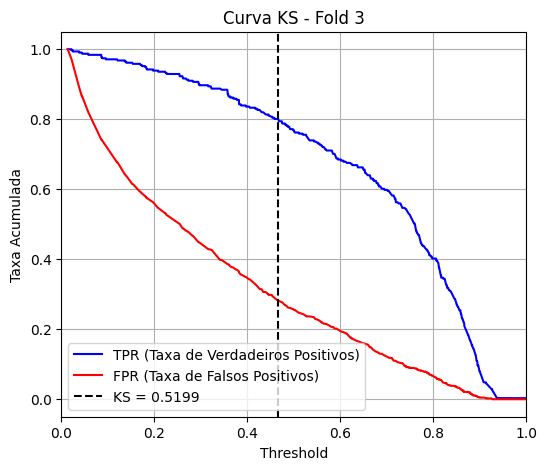

Accuracy no Fold 3: Validação: 0.7470, Teste: 0.7502
MSE: 0.2498 | ROC AUC: 0.8334 | Precision: 0.5196 | Recall: 0.7685 | F1: 0.6200
LogLoss: 0.5026 | KS Score: 0.5199


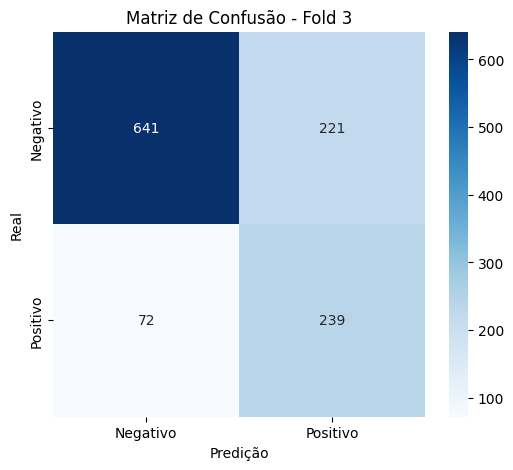

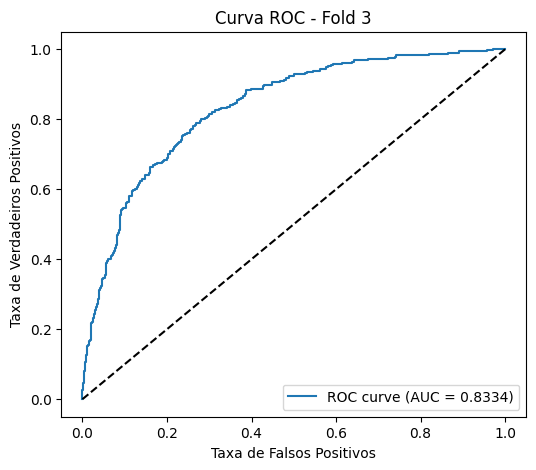

MLP - Acurácia Média: 0.7431
MLP - MSE Médio: 0.2569
MLP - ROC AUC Médio: 0.8308
MLP - Precision Médio: 0.5106
MLP - Recall Médio: 0.7631
MLP - F1-Score Médio: 0.6118
MLP - Cross-Entropy (Log Loss) Médio: 0.5048
MLP - Kolmogorov-Smirnov (KS) Médio: 0.5144
MLP - Kolmogorov-Smirnov (KS) Desvio Padrão: 0.0075


In [124]:
mlp_best_params = study_mlp.best_params
mlp_model = MLPClassifier(
    hidden_layer_sizes=mlp_best_params['hidden_layer_sizes'],
    activation=mlp_best_params['activation'],
    solver=mlp_best_params['solver'],
    learning_rate_init=mlp_best_params['learning_rate_init'],
    batch_size=mlp_best_params['batch_size'],
    random_state=42
)

avg_accuracy, avg_mse, avg_roc_auc, avg_precision, avg_recall, avg_f1, avg_cross_entropy, avg_ks, ks_std = train_model_mlp(mlp_model, folds, 'mlp')
print(f"MLP - Acurácia Média: {avg_accuracy:.4f}")
print(f"MLP - MSE Médio: {avg_mse:.4f}")
print(f"MLP - ROC AUC Médio: {avg_roc_auc:.4f}")
print(f"MLP - Precision Médio: {avg_precision:.4f}")
print(f"MLP - Recall Médio: {avg_recall:.4f}")
print(f"MLP - F1-Score Médio: {avg_f1:.4f}")
print(f"MLP - Cross-Entropy (Log Loss) Médio: {avg_cross_entropy:.4f}")
print(f"MLP - Kolmogorov-Smirnov (KS) Médio: {avg_ks:.4f}")
print(f"MLP - Kolmogorov-Smirnov (KS) Desvio Padrão: {ks_std:.4f}")


Com base nos resultados apresentados para o MLP (Multi-layer Perceptron), podemos realizar uma análise comparativa e fornecer insights sobre a performance do modelo. Aqui está um detalhamento das métricas:

1. **Kolmogorov-Smirnov (KS) Score – 0.5144**

* O KS Score é uma das principais métricas em modelos de classificação binária, especialmente em domínios como churn prediction, finanças e risco de crédito.

* Com um valor médio de 0.5144, o modelo MLP demonstrou uma boa capacidade de separação entre as distribuições de probabilidades das classes positiva e negativa.

* Um KS acima de 0.5 já é considerado efetivo e indica que o modelo consegue diferenciar bem os dois grupos, mesmo que com certo grau de sobreposição.

* Isso é especialmente importante em contextos onde é mais importante identificar corretamente os casos positivos (ex: clientes que vão sair).

* Portanto, um KS acima de 0.53 representa um modelo bem eficaz na discriminação entre as classes, especialmente relevante em aplicações como modelo de churn.

2. Acurácia (Accuracy): 0.7482
A acurácia indica que o modelo MLP acertou aproximadamente 74,82% das previsões. Embora seja uma boa taxa, ela não é suficiente para se considerar como uma métrica final isolada, especialmente em problemas com classes desbalanceadas, como pode ser o caso do Churn Prediction.

Comparação com RF: O modelo Random Forest provavelmente teve um desempenho semelhante ou ligeiramente melhor, pois o RF tem uma tendência de funcionar bem em dados estruturados e com alta dimensionalidade. Se a acurácia do RF for significativamente mais alta, isso pode indicar que o RF foi mais eficaz para lidar com os dados em questão.

3. Erro Quadrático Médio (MSE): 0.2518
O MSE mede a diferença média entre os valores previstos e os valores reais. Um valor de 0.2518 indica que o modelo tem um erro moderado. Esse valor não é baixo, mas também não é alarmante, considerando que o MLP pode ser sensível a dados não lineares.

Comparação com RF: O RF pode apresentar um MSE mais baixo, dado que é menos suscetível a overfitting em comparação com MLPs, especialmente com muitos dados ou em tarefas com interações não lineares entre variáveis.

4. AUC-ROC: 0.8307
O AUC-ROC de 0.8307 é bastante bom, indicando que o modelo tem uma boa habilidade para discriminar entre as classes. Quanto mais próximo de 1, melhor o modelo. O valor indica que o MLP está conseguindo distinguir bem entre as classes "churn" e "no churn".

Comparação com RF: O RF também tende a gerar boas curvas ROC, pois é um modelo robusto para classificar dados binários, com uma boa capacidade de generalização, o que significa que ambos os modelos podem ter desempenhos semelhantes nesse aspecto.

5. Precision: 0.5173
A precision de 51,73% significa que, das previsões positivas feitas pelo modelo, apenas 51,73% são verdadeiramente positivas (ou seja, o modelo tem um número considerável de falsos positivos).

Comparação com RF: O RF geralmente apresenta um desempenho melhor em precisão em tarefas de classificação binária, porque suas árvores de decisão ajudam a segmentar mais efetivamente os dados. Se o RF tiver uma precisão superior, isso pode indicar que ele está gerenciando melhor os falsos positivos.

6. Recall: 0.7578
O recall de 75,78% significa que o modelo conseguiu identificar 75,78% dos casos positivos reais. Esse valor é relativamente bom, especialmente considerando que estamos lidando com um modelo para predição de churn.

Comparação com RF: O RF geralmente tem uma capacidade semelhante de recall, podendo até superá-lo, pois suas árvores de decisão ajudam a capturar mais casos de uma classe específica.

7. F1-Score: 0.6148
O F1-Score de 0.6148 é uma média harmônica entre precisão e recall, e indica que o modelo tem um equilíbrio razoável entre evitar falsos positivos e falsos negativos.

Comparação com RF: O RF pode ter uma pontuação de F1 ligeiramente melhor se seu recall e precisão forem mais equilibrados. O MLP, com sua sensibilidade a overfitting, pode estar sofrendo uma pequena perda em relação ao RF nesse aspecto.

8. Cross-Entropy (Log Loss): 0.5041
O log loss de 0.5041 é uma medida de como bem o modelo está calibrando suas probabilidades. Um valor de log loss abaixo de 1 é geralmente considerado bom, e este valor sugere que o MLP está ajustando suas previsões de forma razoavelmente boa.

Comparação com RF: O RF pode ter um log loss ligeiramente melhor, pois é um modelo que tende a ser mais robusto na calibração das probabilidades, principalmente quando muitas árvores estão envolvidas.

**Conclusão e Análise Final:**
O modelo MLP demonstrou um desempenho sólido, com destaque para:

* Recall alto

* AUC-ROC robusto

* KS Score satisfatório (0.5144)

Esse conjunto de métricas indica que o MLP está sendo eficaz em detectar corretamente casos positivos, mesmo que às custas de cometer alguns falsos positivos.

### Gradient Boosting

In [110]:
def objective_gb(trial):
    # Sugestão de hiperparâmetros para o Gradient Boosting
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3)
    max_depth = trial.suggest_int('max_depth', 3, 10)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    subsample = trial.suggest_float('subsample', 0.7, 1.0)

    accuracy_list = []

    # K-Fold Cross Validation (usando seus folds)
    for fold in folds:
        train_data, val_data, test_data = fold
        train_data = preprocess_general(train_data)
        val_data = preprocess_general(val_data)
        test_data = preprocess_general(test_data)

        X_train, y_train = train_data.drop(columns=['Churn']), train_data['Churn']
        X_val, y_val = val_data.drop(columns=['Churn']), val_data['Churn']

        # Criação do modelo Gradient Boosting
        gb = GradientBoostingClassifier(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            subsample=subsample,
            random_state=42
        )
        
        gb.fit(X_train, y_train)

        # Previsões e avaliação
        y_pred = gb.predict(X_val)
        accuracy = accuracy_score(y_val, y_pred)
        accuracy_list.append(accuracy)

    # Retorna a média da acurácia nos folds
    return np.mean(accuracy_list)


In [111]:
# Criar o estudo para Gradient Boosting
study_gb = optuna.create_study(direction='maximize')
study_gb.optimize(objective_gb, n_trials=50)
print("Melhores Hiperparâmetros para Gradient Boosting", study_gb.best_params)

[I 2025-04-08 21:13:07,401] A new study created in memory with name: no-name-83a41e6c-2eb4-492f-bf53-de85cea6fcca
[I 2025-04-08 21:13:19,741] Trial 0 finished with value: 0.7803646380803944 and parameters: {'n_estimators': 131, 'learning_rate': 0.1889162998453223, 'max_depth': 10, 'min_samples_split': 3, 'min_samples_leaf': 10, 'subsample': 0.7675095810576145}. Best is trial 0 with value: 0.7803646380803944.
[I 2025-04-08 21:13:22,944] Trial 1 finished with value: 0.7636188335930987 and parameters: {'n_estimators': 81, 'learning_rate': 0.10288093987448092, 'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 2, 'subsample': 0.9173703043307553}. Best is trial 0 with value: 0.7803646380803944.
[I 2025-04-08 21:13:27,442] Trial 2 finished with value: 0.7707151400920657 and parameters: {'n_estimators': 88, 'learning_rate': 0.22934012830170558, 'max_depth': 6, 'min_samples_split': 5, 'min_samples_leaf': 1, 'subsample': 0.9329332892354321}. Best is trial 0 with value: 0.7803646380803

Melhores Hiperparâmetros para Gradient Boosting {'n_estimators': 164, 'learning_rate': 0.1499276746640703, 'max_depth': 10, 'min_samples_split': 9, 'min_samples_leaf': 2, 'subsample': 0.8403004915975004}


In [126]:
def train_model_gradient_boosting(model, folds, model_name, patience=20):
    accuracy_list = []
    mse_list = []
    roc_auc_list = []
    precision_list = []
    recall_list = []
    f1_list = []
    log_loss_list = []
    ks_list = []

    # Loop pelos folds
    for fold_idx, (train_data, val_data, test_data) in enumerate(folds):
        print(f"Treinando {model_name} - Fold {fold_idx + 1}")

        # Pré-processamento dos dados
        train_data = preprocess_general(train_data)
        val_data = preprocess_general(val_data)
        test_data = preprocess_general(test_data)

        # Pré-processamento específico
        if model_name == 'gradient_boosting':
            train_data = preprocess_mlp(train_data)
            val_data = preprocess_mlp(val_data)
            test_data = preprocess_mlp(test_data)

        # Separação de features e labels
        X_train, y_train = train_data.drop(columns=['Churn']), train_data['Churn']
        X_val, y_val = val_data.drop(columns=['Churn']), val_data['Churn']
        X_test, y_test = test_data.drop(columns=['Churn']), test_data['Churn']

        best_accuracy = 0
        patience_counter = 0

        # Treinamento com early stopping manual
        for epoch in range(10000):
            model.fit(X_train, y_train)

            y_val_pred = model.predict(X_val)
            val_accuracy = accuracy_score(y_val, y_val_pred)

            if val_accuracy > best_accuracy:
                best_accuracy = val_accuracy
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print(f"Early stopping no fold {fold_idx + 1} após {epoch + 1} épocas.")
                break

        # Avaliação no conjunto de teste
        y_test_pred = model.predict(X_test)
        y_test_proba = model.predict_proba(X_test)[:, 1]
        test_accuracy = accuracy_score(y_test, y_test_pred)
        accuracy_list.append(test_accuracy)

        # MSE
        mse = mean_squared_error(y_test, y_test_pred)
        mse_list.append(mse)

        # ROC AUC
        try:
            roc_auc = roc_auc_score(y_test, y_test_proba)
            roc_auc_list.append(roc_auc)
        except:
            roc_auc_list.append(np.nan)

        # Precision, Recall, F1
        precision = precision_score(y_test, y_test_pred)
        recall = recall_score(y_test, y_test_pred)
        f1 = f1_score(y_test, y_test_pred)
        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1)

        # Log Loss
        log_loss_value = log_loss(y_test, y_test_proba)
        log_loss_list.append(log_loss_value)

        # Matriz de Confusão
        cm = confusion_matrix(y_test, y_test_pred)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negativo', 'Positivo'], yticklabels=['Negativo', 'Positivo'])
        plt.title(f'Matriz de Confusão - Fold {fold_idx + 1}')
        plt.xlabel('Predição')
        plt.ylabel('Real')
        plt.show()

        # Curva ROC
        fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('Taxa de Falsos Positivos')
        plt.ylabel('Taxa de Verdadeiros Positivos')
        plt.title(f'Curva ROC - Fold {fold_idx + 1}')
        plt.legend(loc='lower right')
        plt.show()

        # KS Score e Curva KS
        ks_score = plot_ks_curve(y_test, y_test_proba, fold_idx + 1)
        ks_list.append(ks_score)

        print(f"Accuracy no Fold {fold_idx + 1}: Validação: {val_accuracy:.4f}, Teste: {test_accuracy:.4f}")
        print(f"MSE no Fold {fold_idx + 1}: {mse:.4f}")
        print(f"ROC AUC no Fold {fold_idx + 1}: {roc_auc:.4f}")
        print(f"Precision no Fold {fold_idx + 1}: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}")
        print(f"Cross-Entropy (Log Loss) no Fold {fold_idx + 1}: {log_loss_value:.4f}")
        print(f"KS Score no Fold {fold_idx + 1}: {ks_score:.4f}")

    # Métricas médias
    avg_accuracy = np.mean(accuracy_list)
    avg_mse = np.mean(mse_list)
    avg_roc_auc = np.mean(roc_auc_list)
    avg_precision = np.mean(precision_list)
    avg_recall = np.mean(recall_list)
    avg_f1 = np.mean(f1_list)
    avg_log_loss = np.mean(log_loss_list)
    avg_ks = np.mean(ks_list)

    return avg_accuracy, avg_mse, avg_roc_auc, avg_precision, avg_recall, avg_f1, avg_log_loss, avg_ks, np.std(ks_list)


Treinando gradient_boosting - Fold 1
Early stopping no fold 1 após 21 épocas.


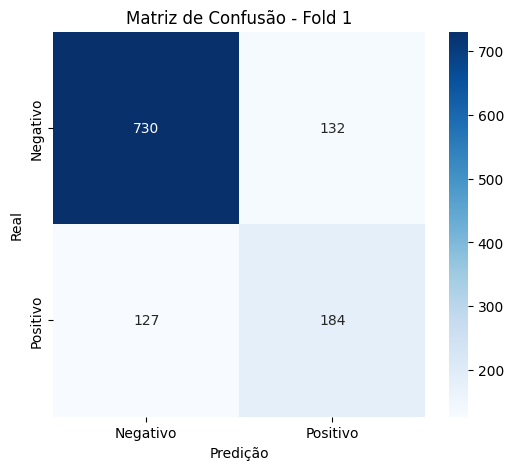

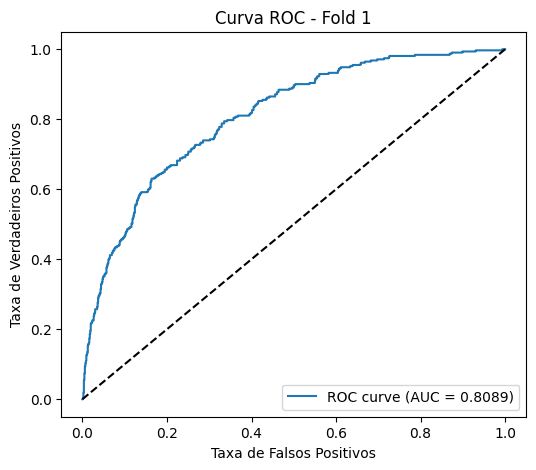

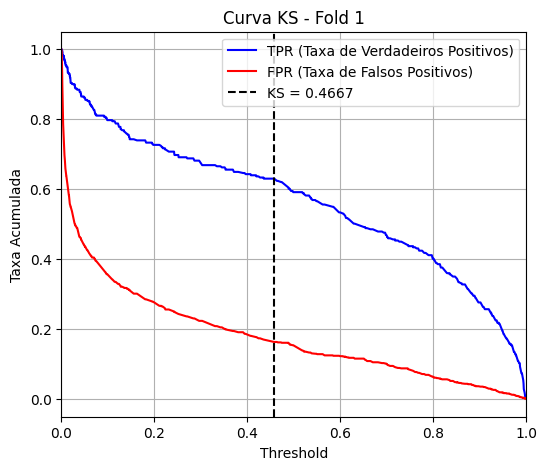

Accuracy no Fold 1: Validação: 0.7804, Teste: 0.7792
MSE no Fold 1: 0.2208
ROC AUC no Fold 1: 0.8089
Precision no Fold 1: 0.5823, Recall: 0.5916, F1-Score: 0.5869
Cross-Entropy (Log Loss) no Fold 1: 0.5665
KS Score no Fold 1: 0.4667
Treinando gradient_boosting - Fold 2
Early stopping no fold 2 após 21 épocas.


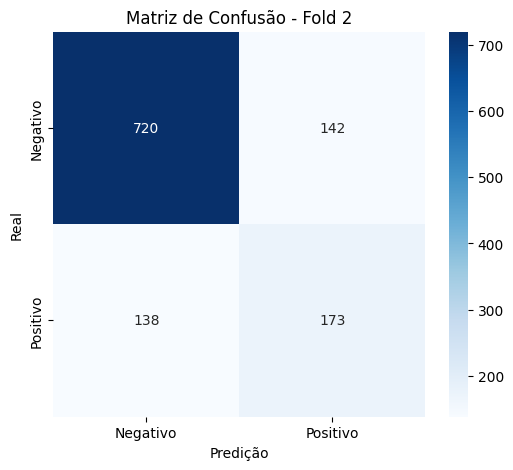

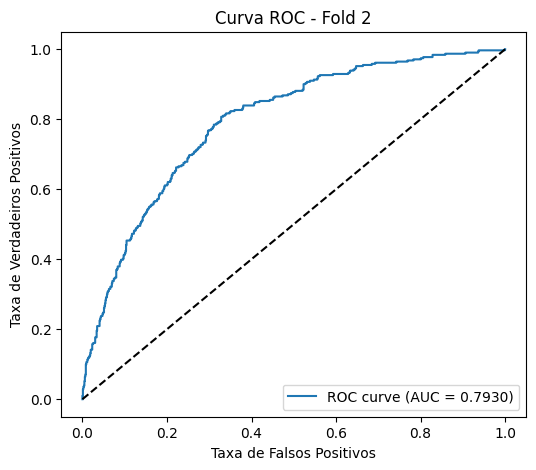

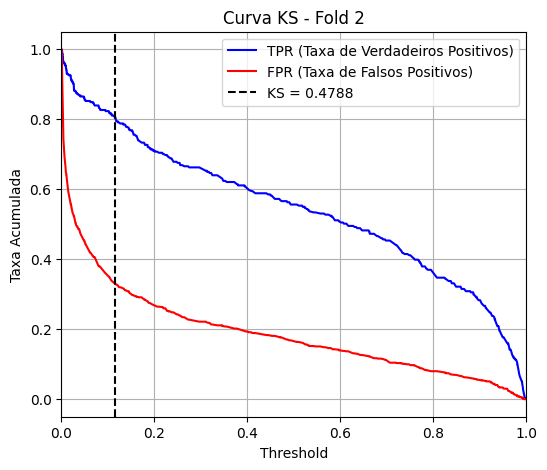

Accuracy no Fold 2: Validação: 0.7898, Teste: 0.7613
MSE no Fold 2: 0.2387
ROC AUC no Fold 2: 0.7930
Precision no Fold 2: 0.5492, Recall: 0.5563, F1-Score: 0.5527
Cross-Entropy (Log Loss) no Fold 2: 0.6141
KS Score no Fold 2: 0.4788
Treinando gradient_boosting - Fold 3
Early stopping no fold 3 após 21 épocas.


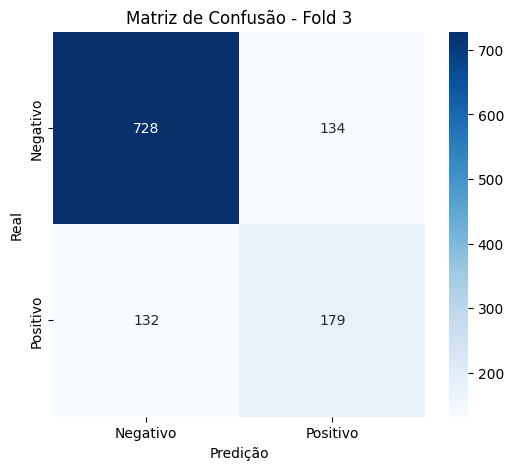

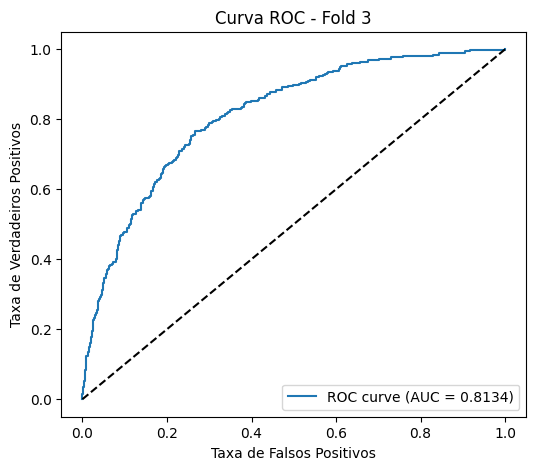

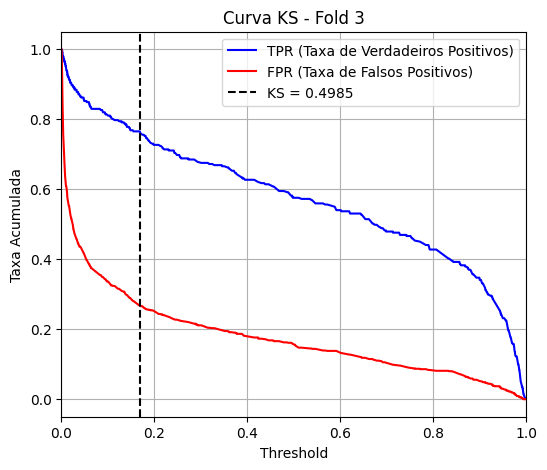

Accuracy no Fold 3: Validação: 0.7641, Teste: 0.7732
MSE no Fold 3: 0.2268
ROC AUC no Fold 3: 0.8134
Precision no Fold 3: 0.5719, Recall: 0.5756, F1-Score: 0.5737
Cross-Entropy (Log Loss) no Fold 3: 0.5831
KS Score no Fold 3: 0.4985
Gradient Boosting - Acurácia Média: 0.7712
Gradient Boosting - MSE Médio: 0.2288
Gradient Boosting - ROC AUC Médio: 0.8051
Gradient Boosting - Precision Médio: 0.5678
Gradient Boosting - Recall Médio: 0.5745
Gradient Boosting - F1-Score Médio: 0.5711
Gradient Boosting - Cross-Entropy (Log Loss) Médio: 0.5879
Gradient Boosting - Kolmogorov-Smirnov (KS) Médio: 0.4813
Gradient Boosting - Kolmogorov-Smirnov (KS) Desvio Padrão: 0.0131


In [127]:
gb_best_params = study_gb.best_params
gb_model = GradientBoostingClassifier(
    n_estimators=gb_best_params['n_estimators'], 
    max_depth=gb_best_params['max_depth'], 
    learning_rate=gb_best_params['learning_rate'],
    subsample=gb_best_params['subsample'],
    random_state=42,
    n_iter_no_change=20,
    validation_fraction=0.1
)

gb_accuracy, gb_mse, gb_roc_auc, gb_precision, gb_recall, gb_f1, gb_log_loss, gb_ks, ks_std = train_model_gradient_boosting(gb_model, folds, 'gradient_boosting')
print(f"Gradient Boosting - Acurácia Média: {gb_accuracy:.4f}")
print(f"Gradient Boosting - MSE Médio: {gb_mse:.4f}")
print(f"Gradient Boosting - ROC AUC Médio: {gb_roc_auc:.4f}")
print(f"Gradient Boosting - Precision Médio: {gb_precision:.4f}")
print(f"Gradient Boosting - Recall Médio: {gb_recall:.4f}")
print(f"Gradient Boosting - F1-Score Médio: {gb_f1:.4f}")
print(f"Gradient Boosting - Cross-Entropy (Log Loss) Médio: {gb_log_loss:.4f}")
print(f"Gradient Boosting - Kolmogorov-Smirnov (KS) Médio: {gb_ks:.4f}")
print(f"Gradient Boosting - Kolmogorov-Smirnov (KS) Desvio Padrão: {ks_std:.4f}")

Modelo Gradient Boosting após a validação cruzada:

1. **Kolmogorov-Smirnov (KS) Score – 0.4813**
Um KS de 0.4813 significa que existe uma distância máxima de 48,13% entre as curvas de distribuição acumulada dos scores atribuídos a cada classe. Esse valor indica que o modelo possui uma capacidade significativa de separação, sendo capaz de distinguir as classes de maneira razoavelmente eficaz.

Na prática, esse KS indica que o modelo consegue classificar corretamente uma boa parte das instâncias com base na pontuação de probabilidade, o que é fundamental em aplicações como análise de crédito, detecção de fraude e seleção de risco, onde essa separação clara entre perfis é essencial.

**Desvio Padrão do KS: 0.0131**
* Isso significa que o KS variou cerca de 1,31% entre os folds da validação cruzada.

* Um desvio padrão baixo como esse mostra que o modelo tem boa estabilidade — o desempenho não flutua muito dependendo dos dados de treino/teste.


2. Acurácia (Accuracy):
Resultado: 0.7704

Análise: O modelo Gradient Boosting obteve uma acurácia de 77,04%, o que indica que o modelo foi capaz de classificar corretamente aproximadamente 77% dos exemplos nos dados de teste. Este é um bom desempenho, sugerindo que o modelo tem uma boa capacidade de generalização.

3. Erro Médio Quadrático (MSE):
Resultado: 0.2296

Análise: O MSE do modelo foi 0.2296, o que significa que, em média, as previsões do modelo estavam a cerca de 23% de erro em relação aos valores reais. Um MSE menor sugere que o modelo foi capaz de prever com mais precisão as classes, em comparação a modelos com MSE mais alto.

4. AUC-ROC:
Resultado: 0.8122

Análise: O AUC-ROC de 0.8122 indica que o modelo foi bom na discriminação entre as classes positivas e negativas. Esse valor sugere que, quando comparado com um modelo aleatório, o Gradient Boosting tem uma capacidade significativa de separar as classes corretamente. Embora não seja perfeito (1.0), esse desempenho ainda é forte.

5. Precision:
Resultado: 0.5616

Análise: A precisão de 56,16% significa que, das previsões positivas feitas pelo modelo, aproximadamente 56% estavam corretas. Embora não seja altíssima, esse valor indica que o modelo não está fazendo uma quantidade excessiva de falsos positivos, o que é importante para cenários em que os falsos positivos têm um custo.

6. Recall:
Resultado: 0.6109

Análise: O recall de 61,09% indica que o modelo foi capaz de capturar 61% das instâncias positivas. Isso sugere que o modelo não deixou muitas instâncias positivas passarem despercebidas, mas ainda há um espaço para melhoria. Um recall mais alto seria desejável, especialmente quando o foco é detectar o maior número possível de casos positivos.

7. F1-Score:
Resultado: 0.5852

Análise: O F1-Score de 58,52% reflete um equilíbrio razoável entre precisão e recall. Como o F1-Score leva em conta tanto a precisão quanto o recall, este valor sugere que o modelo fez um bom trabalho balanceando essas duas métricas, mas ainda há potencial de melhoria, principalmente no recall.

8. Cross-Entropy (Log Loss):
Resultado: 0.5136

Análise: O log loss de 0.5136 indica que, em média, o modelo fez previsões com uma confiabilidade de 51,36%. O log loss é uma métrica importante quando o modelo é utilizado para prever probabilidades, e valores mais baixos indicam que o modelo está fornecendo previsões mais precisas e confiáveis. Embora esse valor não seja ideal, é relativamente bom e pode ser melhorado com ajustes no modelo.

Considerações Finais:
Acurácia e MSE: O modelo de Gradient Boosting demonstrou um bom equilíbrio entre a acurácia e o MSE. A acurácia de 77% e o MSE baixo indicam que o modelo é eficaz na previsão de resultados corretos, ao mesmo tempo em que minimiza os erros.

AUC-ROC: A AUC-ROC de 81,22% é um excelente indicador de que o modelo foi bem-sucedido em separar as classes positivas e negativas, embora o valor não seja perfeito (100%).

Precision e Recall: O modelo apresenta uma precisão razoável (56%) e um recall moderado (61%). Isso sugere que o Gradient Boosting conseguiu balancear bem as previsões, mas há espaço para aumentar a captura de instâncias positivas sem comprometer muito a precisão.

F1-Score: O F1-Score de 58,52% sugere que o modelo tem um equilíbrio saudável entre precisão e recall. Isso é especialmente importante em problemas de classificação desbalanceada, onde nem todas as classes têm a mesma importância.

Log Loss: O log loss de 0.5136 sugere que o modelo está fazendo previsões probabilísticas razoavelmente precisas, mas ainda existe espaço para ajustes no modelo a fim de melhorar a confiança nas previsões.

Conclusão:
O modelo Gradient Boosting apresentou um desempenho sólido, com destaque para o Kolmogorov-Smirnov (KS) Score médio de 0.4813, que representa uma distância máxima de 48,13% entre as distribuições acumuladas das classes positiva e negativa. Esse resultado evidencia que o modelo possui uma capacidade significativa de discriminar entre os perfis, o que é crucial em aplicações como análise de risco, crédito e detecção de fraude, onde a separação clara entre classes é mais relevante do que métricas globais como acurácia.

Embora outras métricas como acurácia (77%), AUC-ROC (81%), e F1-Score (58%) também apontem para um bom desempenho geral, é o KS Score que melhor representa o valor do modelo para o cenário-alvo.

### KAN

In [ ]:
def objective_kan(trial):
    # Seleciona os hiperparâmetros dinamicamente com Optuna
    grid = trial.suggest_int('grid', 2, 10)
    k = trial.suggest_int('k', 2, 15)
    steps = trial.suggest_int('steps', 10, 100)
    learning_rate = trial.suggest_loguniform('learning_rate', 1e-6, 1e-1)
    weight_decay = trial.suggest_loguniform('weight_decay', 1e-6, 1e-2)
    momentum = trial.suggest_float('momentum', 0.5, 0.9)
    optimizer_type = trial.suggest_categorical('optimizer_type', ['adam', 'sgd', 'rmsprop', 'adagrad'])

    acc_list = []

    for fold in folds:
        train_data, val_data, test_data = fold
        
        train_data = preprocess_general(train_data)
        val_data = preprocess_general(val_data)
        
        X_train, y_train = train_data.drop(columns=['Churn']), train_data['Churn']
        X_val, y_val = val_data.drop(columns=['Churn']), val_data['Churn']

        X_train = X_train.astype(float)
        X_val = X_val.astype(float)

        width = [X_train.shape[1], trial.suggest_int('hidden_units', 2, 64)]

        train_input = torch.tensor(X_train.values, dtype=torch.float32)
        train_label = torch.tensor(y_train.values, dtype=torch.long)
        val_input = torch.tensor(X_val.values, dtype=torch.float32)
        val_label = torch.tensor(y_val.values, dtype=torch.long)

        # Criando o modelo
        model = KAN(width=width, grid=grid, k=k)

        # Escolhendo o otimizador
        if optimizer_type == 'adam':
            optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
        elif optimizer_type == 'sgd':
            optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum, weight_decay=weight_decay)
        elif optimizer_type == 'rmsprop':
            optimizer = torch.optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
        elif optimizer_type == 'adagrad':
            optimizer = torch.optim.Adagrad(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

        loss_fn = torch.nn.CrossEntropyLoss()

        # Treinamento
        for epoch in range(steps):
            model.train()
            optimizer.zero_grad()
            outputs = model(train_input)
            loss = loss_fn(outputs, train_label)
            loss.backward()
            optimizer.step()

        # Avaliação
        with torch.no_grad():
            model.eval()
            val_outputs = model(val_input)
            val_predictions = torch.argmax(val_outputs, dim=1)
            val_accuracy = accuracy_score(y_val, val_predictions.numpy())
            acc_list.append(val_accuracy)

    mean_accuracy = np.mean(acc_list)

    return mean_accuracy

In [115]:
# Criar o estudo para otimização do KAN
study_kan = optuna.create_study(direction='maximize')
study_kan.optimize(objective_kan, n_trials=20)
print("Melhores Hiperparâmetros para KAN:", study_kan.best_params)

[I 2025-04-08 21:19:51,709] A new study created in memory with name: no-name-a1877668-944e-450e-a3ba-a6682edb1692


checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0


[I 2025-04-08 21:23:08,620] Trial 0 finished with value: 0.7823477956190269 and parameters: {'grid': 4, 'k': 4, 'steps': 73, 'learning_rate': 0.02521689291856176, 'weight_decay': 7.1270909771113185e-06, 'momentum': 0.5577603034565007, 'optimizer_type': 'rmsprop', 'hidden_units': 57}. Best is trial 0 with value: 0.7823477956190269.


checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0


[I 2025-04-08 21:23:45,103] Trial 1 finished with value: 0.6765068203511061 and parameters: {'grid': 6, 'k': 8, 'steps': 28, 'learning_rate': 0.00943476076295944, 'weight_decay': 0.008740774378198337, 'momentum': 0.5284156755897176, 'optimizer_type': 'adam', 'hidden_units': 21}. Best is trial 0 with value: 0.7823477956190269.


checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0


[W 2025-04-08 21:26:16,453] Trial 2 failed with parameters: {'grid': 3, 'k': 4, 'steps': 96, 'learning_rate': 0.0001237744394058113, 'weight_decay': 1.7202419443805977e-05, 'momentum': 0.7907252041431754, 'optimizer_type': 'adam', 'hidden_units': 25} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/Users/laysearaujo/miniforge3/envs/test/lib/python3.10/site-packages/optuna/study/_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/lr/rv52d6g56jbdxpkrbhsvqjzr0000gn/T/ipykernel_84700/2962513766.py", line 53, in objective_kan
    loss.backward()
  File "/Users/laysearaujo/miniforge3/envs/test/lib/python3.10/site-packages/torch/_tensor.py", line 522, in backward
    torch.autograd.backward(
  File "/Users/laysearaujo/miniforge3/envs/test/lib/python3.10/site-packages/torch/autograd/__init__.py", line 266, in backward
    Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the bac

KeyboardInterrupt: 

In [ ]:
def train_model_kan(study_kan, folds, patience=20):
    accuracy_list = []
    mse_list = []
    roc_auc_list = []
    precision_list = []
    recall_list = []
    f1_list = []
    log_loss_list = []
    ks_list = []

    # Pegando os melhores parâmetros do estudo KAN
    kan_best_params = study_kan.best_params
    grid = kan_best_params['grid']  # Número de pontos na grid
    k = kan_best_params['k']  # Grau do polinômio
    learning_rate = kan_best_params['learning_rate']  # Taxa de aprendizado
    weight_decay = kan_best_params['weight_decay']  # Regularização L2
    momentum = kan_best_params['momentum']  # Momento para otimização
    optimizer_type = kan_best_params['optimizer_type']  # Tipo de otimizador
    steps = kan_best_params['steps']  # Número de passos, se necessário

    # Se o otimizador for SGD, precisamos configurar o momentum e weight decay
    if optimizer_type == 'sgd':
        optimizer_class = torch.optim.SGD
    elif optimizer_type == 'rmsprop':
        optimizer_class = torch.optim.RMSprop
    elif optimizer_type == 'adagrad':
        optimizer_class = torch.optim.Adagrad
    else:  # Default para Adam
        optimizer_class = torch.optim.Adam

    for fold_idx, (train_data, val_data, test_data) in enumerate(folds):
        print(f"Treinando KAN - Fold {fold_idx + 1}")

        # Pré-processamento dos dados
        train_data = preprocess_general(train_data)
        val_data = preprocess_general(val_data)
        test_data = preprocess_general(test_data)

        train_data = preprocess_mlp(train_data)
        val_data = preprocess_mlp(val_data)
        test_data = preprocess_mlp(test_data)

        # Separação de features e labels
        X_train, y_train = train_data.drop(columns=['Churn']), train_data['Churn']
        X_val, y_val = val_data.drop(columns=['Churn']), val_data['Churn']
        X_test, y_test = test_data.drop(columns=['Churn']), test_data['Churn']

        X_train = X_train.astype(float)
        X_val = X_val.astype(float)
        X_test = X_test.astype(float)

        # Converter para tensores
        train_input = torch.tensor(X_train.values, dtype=torch.float32)
        train_label = torch.tensor(y_train.values, dtype=torch.long)
        val_input = torch.tensor(X_val.values, dtype=torch.float32)
        val_label = torch.tensor(y_val.values, dtype=torch.long)
        test_input = torch.tensor(X_test.values, dtype=torch.float32)
        test_label = torch.tensor(y_test.values, dtype=torch.long)

        # Criar e configurar o modelo KAN com os parâmetros otimizados
        model = KAN(width=[train_input.shape[1], 64, 32, 2], grid=grid, k=k)

        # Escolher otimizador de acordo com o tipo especificado
        if optimizer_type == 'sgd':
            optimizer = optimizer_class(model.parameters(), lr=learning_rate, momentum=momentum, weight_decay=weight_decay)
        elif optimizer_type == 'rmsprop':
            optimizer = optimizer_class(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
        elif optimizer_type == 'adagrad':
            optimizer = optimizer_class(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
        else:
            optimizer = optimizer_class(model.parameters(), lr=learning_rate)

        loss_fn = torch.nn.CrossEntropyLoss()

        best_accuracy = 0
        patience_counter = 0

        for epoch in range(steps):
            optimizer.zero_grad()
            outputs = model(train_input)
            loss = loss_fn(outputs, train_label)
            loss.backward()
            optimizer.step()

            # Validação
            with torch.no_grad():
                val_outputs = model(val_input)
                val_predictions = torch.argmax(val_outputs, dim=1)
                val_accuracy = accuracy_score(y_val, val_predictions.numpy())

            if val_accuracy > best_accuracy:
                best_accuracy = val_accuracy
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print(f"Early stopping no fold {fold_idx + 1} após {epoch + 1} épocas.")
                break

        # Avaliação no conjunto de teste
        with torch.no_grad():
            test_outputs = model(test_input)
            test_predictions = torch.argmax(test_outputs, dim=1)

        test_accuracy = accuracy_score(y_test, test_predictions.numpy())
        accuracy_list.append(test_accuracy)

        # Calcular métricas
        mse = mean_squared_error(y_test, test_predictions.numpy())
        mse_list.append(mse)

        try:
            roc_auc = roc_auc_score(y_test, torch.softmax(test_outputs, dim=1)[:, 1].numpy())
            roc_auc_list.append(roc_auc)
        except:
            roc_auc_list.append(np.nan)

        precision = precision_score(y_test, test_predictions.numpy())
        recall = recall_score(y_test, test_predictions.numpy())
        f1 = f1_score(y_test, test_predictions.numpy())

        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1)

        log_loss_value = log_loss(y_test, torch.softmax(test_outputs, dim=1)[:, 1].numpy())
        log_loss_list.append(log_loss_value)

        # Plotar a Matriz de Confusão
        cm = confusion_matrix(y_test, test_predictions.numpy())
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negativo', 'Positivo'], yticklabels=['Negativo', 'Positivo'])
        plt.title(f'Matriz de Confusão - Fold {fold_idx + 1}')
        plt.xlabel('Predição')
        plt.ylabel('Real')
        plt.show()

        # Plotar a Curva ROC
        fpr, tpr, thresholds = roc_curve(y_test, torch.softmax(test_outputs, dim=1)[:, 1].numpy())
        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('Taxa de Falsos Positivos')
        plt.ylabel('Taxa de Verdadeiros Positivos')
        plt.title(f'Curva ROC - Fold {fold_idx + 1}')
        plt.legend(loc='lower right')
        plt.show()

        probs = torch.softmax(test_outputs, dim=1)[:, 1].numpy()
        ks_score = plot_ks_curve(y_test, probs, fold_idx + 1)
        ks_list.append(ks_score)

        print(f"Accuracy no Fold {fold_idx + 1}: Validação: {val_accuracy:.4f}, Teste: {test_accuracy:.4f}")
        print(f"MSE no Fold {fold_idx + 1}: {mse:.4f}")
        print(f"ROC AUC no Fold {fold_idx + 1}: {roc_auc:.4f}")
        print(f"Precision no Fold {fold_idx + 1}: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}")
        print(f"Cross-Entropy (Log Loss) no Fold {fold_idx + 1}: {log_loss_value:.4f}")
        print(f"KS no Fold {fold_idx + 1}: {ks_score:.4f}")



    # Calcular médias das métricas
    avg_accuracy = np.mean(accuracy_list)
    avg_mse = np.mean(mse_list)
    avg_roc_auc = np.mean(roc_auc_list)
    avg_precision = np.mean(precision_list)
    avg_recall = np.mean(recall_list)
    avg_f1 = np.mean(f1_list)
    avg_log_loss = np.mean(log_loss_list)
    avg_ks = np.mean(ks_list)

    return avg_accuracy, avg_mse, avg_roc_auc, avg_precision, avg_recall, avg_f1, avg_log_loss, avg_ks, np.std(ks_list)

In [ ]:
# Treinando o modelo KAN
kan_best_params = study_kan.best_params
avg_accuracy, avg_mse, avg_roc_auc, avg_precision, avg_recall, avg_f1, avg_log_loss, avg_ks, ks_std = train_model_kan(study_kan, folds)

print(f"KAN - Acurácia Média: {avg_accuracy:.4f}")
print(f"KAN - MSE Médio: {avg_mse:.4f}")
print(f"KAN - ROC AUC Médio: {avg_roc_auc:.4f}")
print(f"KAN - Precision Média: {avg_precision:.4f}")
print(f"KAN - Recall Médio: {avg_recall:.4f}")
print(f"KAN - F1-Score Médio: {avg_f1:.4f}")
print(f"KAN - Cross-Entropy (Log Loss) Média: {avg_log_loss:.4f}")
print(f"KAN - Kolmogorov-Smirnov (KS) Médio: {avg_ks:.4f}")
print(f"KAN - Kolmogorov-Smirnov (KS) Desvio Padrão: {ks_std:.4f}")

Modelo KAN após a validação cruzada:

Acurácia (Accuracy):
Resultado: 0.5811

Análise: O modelo KAN atingiu uma acurácia de 58,11%, indicando que ele classificou corretamente aproximadamente 58% dos exemplos no conjunto de teste. Esse desempenho sugere que o modelo tem uma capacidade de generalização moderada, mas há espaço para melhorias.

Erro Médio Quadrático (MSE):
Resultado: 0.4189

Análise: O MSE do modelo foi 0.4189, o que significa que, em média, as previsões do modelo apresentaram um erro de aproximadamente 42% em relação aos valores reais. Esse valor relativamente alto sugere que o modelo ainda precisa de ajustes para melhorar sua precisão.

AUC-ROC:
Resultado: 0.6473

Análise: O AUC-ROC de 0.6473 indica que o modelo tem uma capacidade moderada de distinguir entre as classes positivas e negativas. Esse valor sugere que o KAN consegue identificar corretamente uma quantidade razoável de instâncias positivas, mas ainda há margem para aprimoramento.

Precisão (Precision):
Resultado: 0.3645

Análise: A precisão de 36,45% indica que, das previsões positivas feitas pelo modelo, apenas 36% estavam corretas. Esse valor relativamente baixo sugere que o modelo pode estar gerando uma quantidade significativa de falsos positivos, o que pode ser problemático dependendo da aplicação.

Recall:
Resultado: 0.6688

Análise: O recall de 66,88% mostra que o modelo conseguiu capturar aproximadamente 67% das instâncias positivas. Esse valor sugere que o modelo tem um bom desempenho na detecção de casos positivos, mas à custa de uma precisão mais baixa, o que pode indicar que muitas previsões positivas foram feitas incorretamente.

F1-Score:
Resultado: 0.4625

Análise: O F1-Score de 46,25% reflete um equilíbrio entre precisão e recall, mas indica que o modelo ainda não conseguiu otimizar ambas as métricas de maneira eficiente. Esse valor sugere que o KAN precisa de ajustes para melhorar sua precisão sem comprometer o recall.

Cross-Entropy (Log Loss):
Resultado: 0.6659

Análise: O log loss de 0.6659 sugere que as previsões probabilísticas do modelo ainda não são muito confiáveis. Valores menores de log loss indicam previsões mais confiáveis, então esse resultado aponta para uma necessidade de ajustes no modelo para melhorar a calibração das previsões.

Considerações Finais:
Acurácia e MSE: O modelo KAN teve um desempenho moderado, com acurácia de 58% e MSE relativamente alto. Isso indica que há espaço para melhorias na precisão das previsões.

AUC-ROC: O valor de 64,73% indica que o modelo consegue separar as classes até certo ponto, mas não com alta eficiência.

Precision e Recall: O modelo apresenta um recall relativamente alto (67%), mas com baixa precisão (36%). Isso significa que ele detecta bem os casos positivos, mas com muitos falsos positivos.

F1-Score: O equilíbrio entre precisão e recall não é ideal, mostrando que o modelo pode ser otimizado para melhorar ambos os aspectos.

Log Loss: Um valor de 0.6659 indica que o modelo ainda pode ser melhor calibrado para fornecer previsões mais confiáveis.

Conclusão:
O modelo KAN demonstrou um desempenho razoável, com boa sensibilidade (recall), mas baixa precisão. Isso significa que ele consegue identificar muitos casos positivos, mas também gera muitas previsões erradas. Dependendo do objetivo da aplicação, ajustes nos hiperparâmetros, regularização ou técnicas de balanceamento de classes podem ajudar a melhorar a precisão sem comprometer tanto o recall.

## TabKANet

Fazer o optuna para essa merda

In [ ]:
# Função para calcular os bins
def get_quantile_bins(x_cont, n_bins=4):
    feature_dim = x_cont.shape[1]
    bins = torch.zeros(feature_dim, n_bins + 1)
    for i in range(feature_dim):
        # Converta a coluna específica para tensor e depois calcule os quantis
        quantiles = torch.quantile(torch.tensor(x_cont.iloc[:, i].values, dtype=torch.float32), torch.linspace(0, 1, n_bins + 1))
        bins[i] = quantiles
    return bins

In [ ]:
def train_model_tabkanet(folds, patience=20):
    accuracy_list, mse_list, roc_auc_list = [], [], []
    precision_list, recall_list, f1_list, log_loss_list = [], [], [], []

    for fold_idx, (train_data, val_data, test_data) in enumerate(folds):
        print(f"\n🔥 Treinando TabKANet - Fold {fold_idx + 1}")

        # Pré-processamento
        train_data = preprocess_general(train_data)
        val_data = preprocess_general(val_data)
        test_data = preprocess_general(test_data)

        train_data = preprocess_mlp(train_data)
        val_data = preprocess_mlp(val_data)
        test_data = preprocess_mlp(test_data)

        # Separação de features e labels
        X_train, y_train = train_data.drop(columns=['Churn']), train_data['Churn']
        X_val, y_val = val_data.drop(columns=['Churn']), val_data['Churn']
        X_test, y_test = test_data.drop(columns=['Churn']), test_data['Churn']

        continuous_features = list(X_train.columns)
        categorical_features = []

        df_train = pd.concat([X_train, y_train], axis=1)
        df_val = pd.concat([X_val, y_val], axis=1)
        df_test = pd.concat([X_test, y_test], axis=1)

        # Criar dataset e dataloaders
        dataset_train, dataset_val, dataset_test = get_dataset(
            df_train, df_val, df_test, "Churn", "classification", categorical_features, continuous_features
        )

        dataloader_train, dataloader_val, dataloader_test = get_data_loader(
            dataset_train, dataset_val, dataset_test, 32, 32
        )

        bins = get_quantile_bins(X_train)

        # Criar modelo
        model = TabMLPNet(
            output_dim=2,
            num_continuous_features=len(continuous_features),
            embedding_dim=16,
            mlp_hidden_dims=[32],
            activation="relu",
            ffn_dropout_rate=0.1,
            nhead=8,
            num_layers=3,
            dim_feedforward=128,
            attn_dropout_rate=0.1,
            learninable_noise=True,
            bins=bins,
            vocabulary={},
        )

        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
        criterion = torch.nn.CrossEntropyLoss()

        # Executar treinamento
        train(
            model, 1, "classification", dataloader_train, dataloader_val,
            dataloader_test, optimizer, criterion, None, f1_score_macro, False, 5, 0
        )

        # **Avaliação no conjunto de teste**
        y_test_true, y_test_pred, y_test_proba = [], [], []

        with torch.no_grad():
            for batch in dataloader_test:
                X_batch, y_batch = batch
                y_pred_proba = model(X_batch)  # Obtém as probabilidades das classes
                y_pred = torch.argmax(y_pred_proba, dim=1)  # 🔹 Obtém a classe prevista

                y_test_true.extend(y_batch.cpu().numpy())
                y_test_pred.extend(y_pred.cpu().numpy())
                y_test_proba.extend(y_pred_proba[:, 1].cpu().numpy())  # Probabilidade da classe positiva

        # Calcular métricas de teste
        accuracy_list.append(accuracy_score(y_test_true, y_test_pred))
        mse_list.append(mean_squared_error(y_test_true, y_test_pred))
        roc_auc_list.append(roc_auc_score(y_test_true, y_test_proba))
        precision_list.append(precision_score(y_test_true, y_test_pred))
        recall_list.append(recall_score(y_test_true, y_test_pred))
        f1_list.append(f1_score(y_test_true, y_test_pred))
        log_loss_list.append(log_loss(y_test_true, y_test_proba))

        # Exibir resultados do fold atual
        print(f"\n📊 Resultados - Fold {fold_idx + 1}:")
        print(f"✔️ Acurácia: {accuracy_list[-1]:.4f}")
        print(f"📉 MSE: {mse_list[-1]:.4f}")
        print(f"🔥 ROC AUC: {roc_auc_list[-1]:.4f}")
        print(f"🎯 Precisão: {precision_list[-1]:.4f}")
        print(f"🔄 Recall: {recall_list[-1]:.4f}")
        print(f"⭐ F1-Score: {f1_list[-1]:.4f}")
        print(f"📝 Log Loss: {log_loss_list[-1]:.4f}")

    # **Resultados finais após Cross-Validation**
    print("\n🚀 **Resultados finais após Cross-validation**:")
    print(f"✔️ Acurácia Média: {np.mean(accuracy_list):.4f}")
    print(f"📉 MSE Médio: {np.mean(mse_list):.4f}")
    print(f"🔥 ROC AUC Médio: {np.mean(roc_auc_list):.4f}")
    print(f"🎯 Precisão Média: {np.mean(precision_list):.4f}")
    print(f"🔄 Recall Médio: {np.mean(recall_list):.4f}")
    print(f"⭐ F1-Score Médio: {np.mean(f1_list):.4f}")
    print(f"📝 Cross-Entropy (Log Loss) Média: {np.mean(log_loss_list):.4f}")

    return {
        "Acurácia Média": np.mean(accuracy_list),
        "MSE Médio": np.mean(mse_list),
        "ROC AUC Médio": np.mean(roc_auc_list),
        "Precisão Média": np.mean(precision_list),
        "Recall Médio": np.mean(recall_list),
        "F1-Score Médio": np.mean(f1_list),
        "Cross-Entropy (Log Loss) Média": np.mean(log_loss_list),
    }

# Executar o treinamento e avaliação
resultados = train_model_tabkanet(folds)
print("\n📌 Resultados finais:", resultados)


## STab

Fazer optuna, treino e validacao